In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import matplotlib.transforms as transforms
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from bq3dplots2 import plot_quantity_map
from q3dfit.linelist import linelist
from astropy import constants
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import pixel_to_skycoord
from reproject import reproject_interp, reproject_exact
from reproject.mosaicking import find_optimal_celestial_wcs

In [3]:
dataread = np.load("4C1971_neighbour_method.line.red.npz", allow_pickle=True)
emlflx = dataread['emlflx'].item()
emlflxerr = dataread['emlflxerr'].item()
emlncomp = dataread['emlncomp'].item()
emlsig = dataread['emlsig'].item()
emlsigerr = dataread['emlsigerr'].item()
emlwav = dataread['emlwav'].item()
emlwaverr = dataread['emlwaverr'].item()
emlweq = dataread['emlweq'].item()
ncols = dataread['ncols'].item()
nrows = dataread['nrows'].item()

In [4]:
ncomp = 5
redshift = 3.5892
line = "[OIII]5007"
disable_ticks = True
percentile_limit = 98
ckms = constants.c.to("km/s")
line_wavelength = list(linelist([line])["lines"])[0]
colormap = "inferno"
diverging_colormap = "bwr"

In [5]:
with fits.open("4C1971_G235H_NRS1_NRS2_s3d.fits") as hdul:
    header = hdul[1].header
    hdu1 = hdul[1]
    wcs_full = WCS(header)
    wcs = wcs_full.celestial
    # wcs.wcs.cd = wcs.pixel_scale_matrix
    wcs_out, shape_out = find_optimal_celestial_wcs([(hdu1.data[0], wcs)], frame="icrs")
    pad = 10
    shape_out = (shape_out[0] + 2 * pad, shape_out[1] + 2 * pad)
    wcs_out.wcs.crpix += pad
    # wcs_out.wcs.cd = wcs_out.pixel_scale_matrix
    # wcs_out.wcs.pc = wcs.wcs.pc
    cd_in = wcs.pixel_scale_matrix
    cd_out = wcs_out.pixel_scale_matrix

    R = cd_out @ np.linalg.inv(cd_in)

    angle = np.degrees(np.arctan2(R[0,1], R[1,1]))

    wcs_rot = wcs.deepcopy()

    theta = np.deg2rad(angle)

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    wcs_rot.wcs.pc = R @ wcs_rot.wcs.pc
    cx, cy = wcs.wcs.crpix
    rot = transforms.Affine2D().translate(-cx, -cy).rotate_deg(-angle).translate(cx, cy)

def align_north(data):
    array_north_aligned, _ = reproject_interp((data, wcs), wcs_out, shape_out=shape_out)
    return array_north_aligned
def align_north_exact(data):
    array_north_aligned, _ = reproject_exact((data, wcs), wcs_out, shape_out=shape_out)
    return array_north_aligned

_, footprint = reproject_interp((np.ones(wcs.array_shape), wcs), wcs_out, shape_out=shape_out)

yy, xx = np.where(footprint > 0)
pad = 1
xmin, xmax = xx.min()-pad, xx.max()+pad
ymin, ymax = yy.min()-pad, yy.max()+pad

In [5]:
# fig, axs = plt.subplots(3, ncomp, figsize=(20,10.5), subplot_kw={"projection": wcs_out})
# contmap = np.load("contmap.npy")
# for i in range(ncomp):
#     fluxpeak = emlflx[f"fc{i+1}pk"][line]
#     lim = np.nanpercentile(fluxpeak, percentile_limit)
#     im0 = axs[0, i].imshow(align_north(fluxpeak.T), origin="lower", cmap=colormap, vmax=lim, vmin=0)
#     cax0 = make_axes_locatable(axs[0, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
#     cb0 = fig.colorbar(im0, cax=cax0, label="$10^{-17}$ erg s$^{-1}$ cm$^{-1}$ micron$^{-1}$")
#     axs[0, i].set_title(f"Flux Peak Component {i+1}")

#     for j in range(3):
#         axs[j, i].contour(align_north(contmap), cmap="Greys", zorder=10, linewidths=0.5)
#         axs[j, i].set_xlim(xmin, xmax)
#         axs[j, i].set_ylim(ymin, ymax)
#         axs[j, i].set_xlabel("RA")
#         axs[j, i].set_ylabel("DEC", labelpad=-1.5)
#         axs[j, i].coords[0].set_major_formatter('dd:mm:ss')
#         axs[j, i].coords[0].set_ticklabel(size=7)
#         axs[j, i].coords[1].set_ticklabel(size=7)

#     sigma = emlsig[f"c{i+1}"][line]
#     lim = np.nanpercentile(sigma, percentile_limit)
#     im1 = axs[1, i].imshow(align_north(sigma.T), origin="lower", cmap=colormap, vmax=lim, vmin=0)
#     cax1 = make_axes_locatable(axs[1, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
#     cb1 = fig.colorbar(im1, cax=cax1, label="km/s")
#     axs[1, i].set_title(f"Line Width (Sigma) Component {i+1}")
    
#     velocity = (emlwav[f"c{i+1}"][line]/((redshift+1)*line_wavelength) - 1) * ckms.value
#     lim = np.max(np.abs(np.nanpercentile(velocity, (100-percentile_limit, percentile_limit))))
#     im2 = axs[2, i].imshow(align_north(velocity.T), origin="lower", cmap=diverging_colormap, vmax=lim, vmin=-lim)
#     cax2 = make_axes_locatable(axs[2, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
#     cb2 = fig.colorbar(im2, cax=cax2)
#     cb2.set_label(label="km/s", labelpad=-9)
#     axs[2, i].set_title(f"Velocity Offset Component {i+1}")

# fig.suptitle(f"{line} Component Maps of 4C+1971", size="xx-large")
# fig.tight_layout(w_pad=0, h_pad=0)

In [6]:
contmap = np.load("contmap.npy")
def velocity_plot_shift(component, shift):
    cd_in = wcs.pixel_scale_matrix
    cd_out = wcs_out.pixel_scale_matrix
    R = cd_out @ np.linalg.inv(cd_in)
    angle = np.degrees(np.arctan2(R[0,1], R[1,1]))
    wcs_rot = wcs.deepcopy()
    theta = np.deg2rad(angle)
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    wcs_rot.wcs.pc = R @ wcs_rot.wcs.pc
    cx, cy = wcs.wcs.crpix
    rot = transforms.Affine2D().translate(-cx, -cy).rotate_deg(-angle).translate(cx, cy)

    fig, ax = plt.subplots(1,1, subplot_kw={"projection": wcs_rot})
    velocity = (emlwav[f"c{component}"][line]/((redshift+1)*line_wavelength) - 1) * ckms.value
    lim = np.max(np.abs(np.nanpercentile(velocity, (100-percentile_limit, percentile_limit))))
    im2 = ax.imshow((velocity - shift).T, origin="lower", cmap=diverging_colormap, vmax=lim, vmin=-lim, interpolation="nearest", transform=rot+ax.get_transform("pixel"))
    ax.contour(contmap, cmap="Greys", zorder=10, linewidths=0.5, transform=rot+ax.get_transform("pixel"))
    cax2 = make_axes_locatable(ax).append_axes("right", size="7%", pad="5%", axes_class = Axes)
    cb2 = fig.colorbar(im2, cax=cax2)
    cb2.set_label(label="km/s", labelpad=1)
    ticks = np.array(cb2.get_ticks())
    ticks_lim = ticks[np.where(np.abs(ticks) < lim)]
    cb2.set_ticks(ticks_lim, labels = (ticks_lim+shift).astype(int))
    ax.set_title(f"Velocity Offset Component {component}")# (Reference at {"+" if shift > 0 else ""}{shift} km/s)")
    ax.set_xlabel("RA")
    ax.set_ylabel("DEC", labelpad=-1.5)
    ax.coords[0].set_major_formatter('dd:mm:ss')
    ax.set_facecolor("black")
    plt.show()

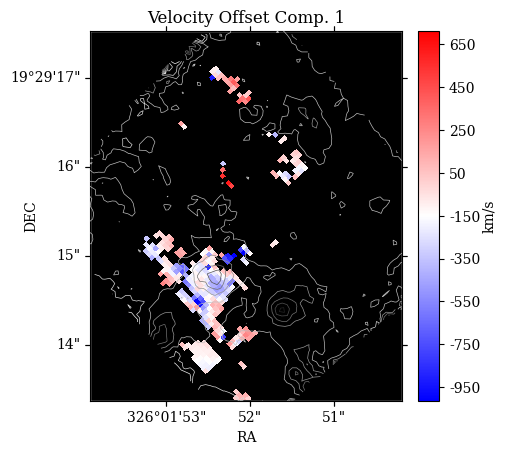

In [7]:
velocity_plot_shift(1, -150)

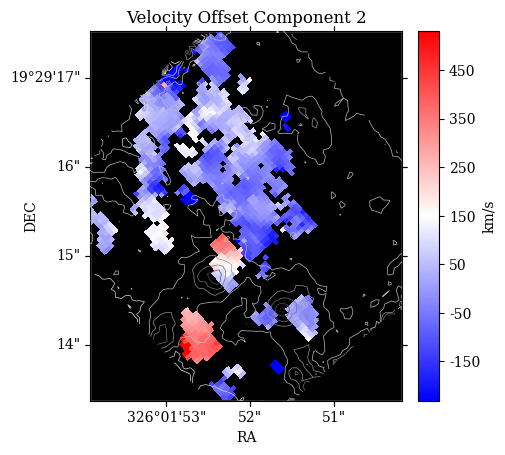

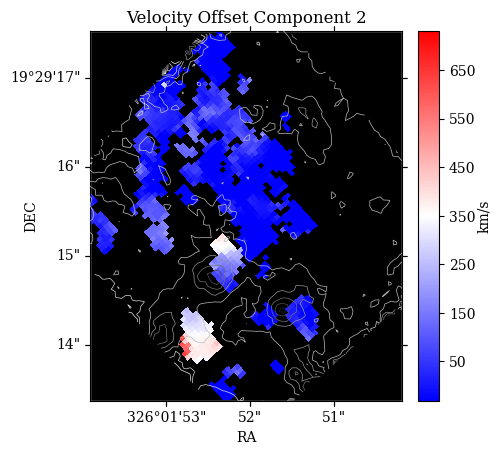

In [14]:
velocity_plot_shift(2, 150)
velocity_plot_shift(2, 350)

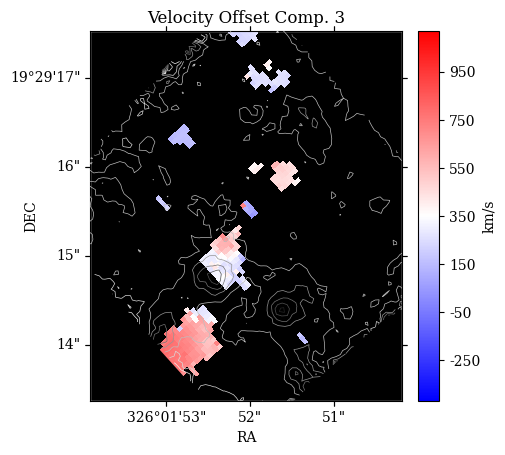

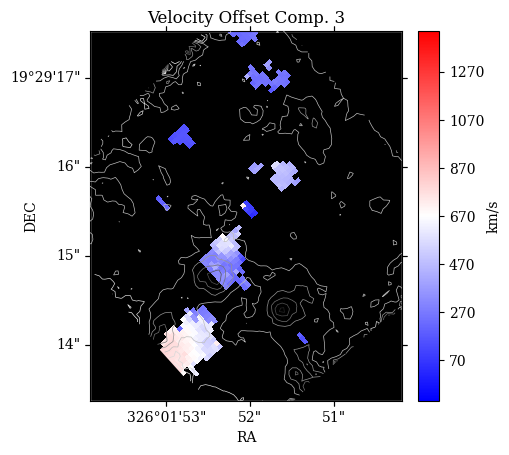

In [9]:
velocity_plot_shift(3, 350)
velocity_plot_shift(3, 670)

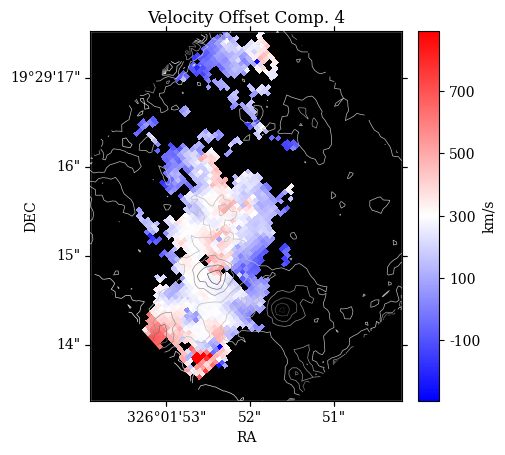

In [10]:
velocity_plot_shift(4, 300)

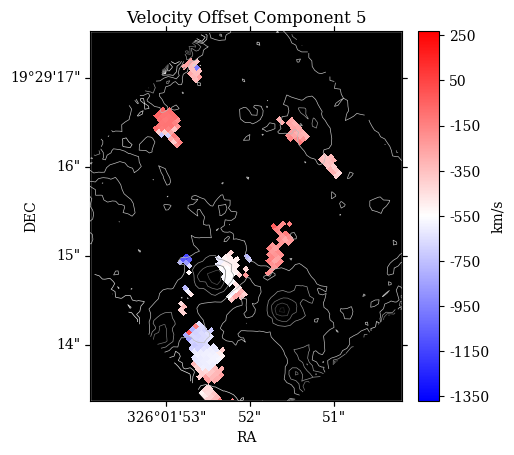

In [72]:
velocity_plot_shift(5, -550)

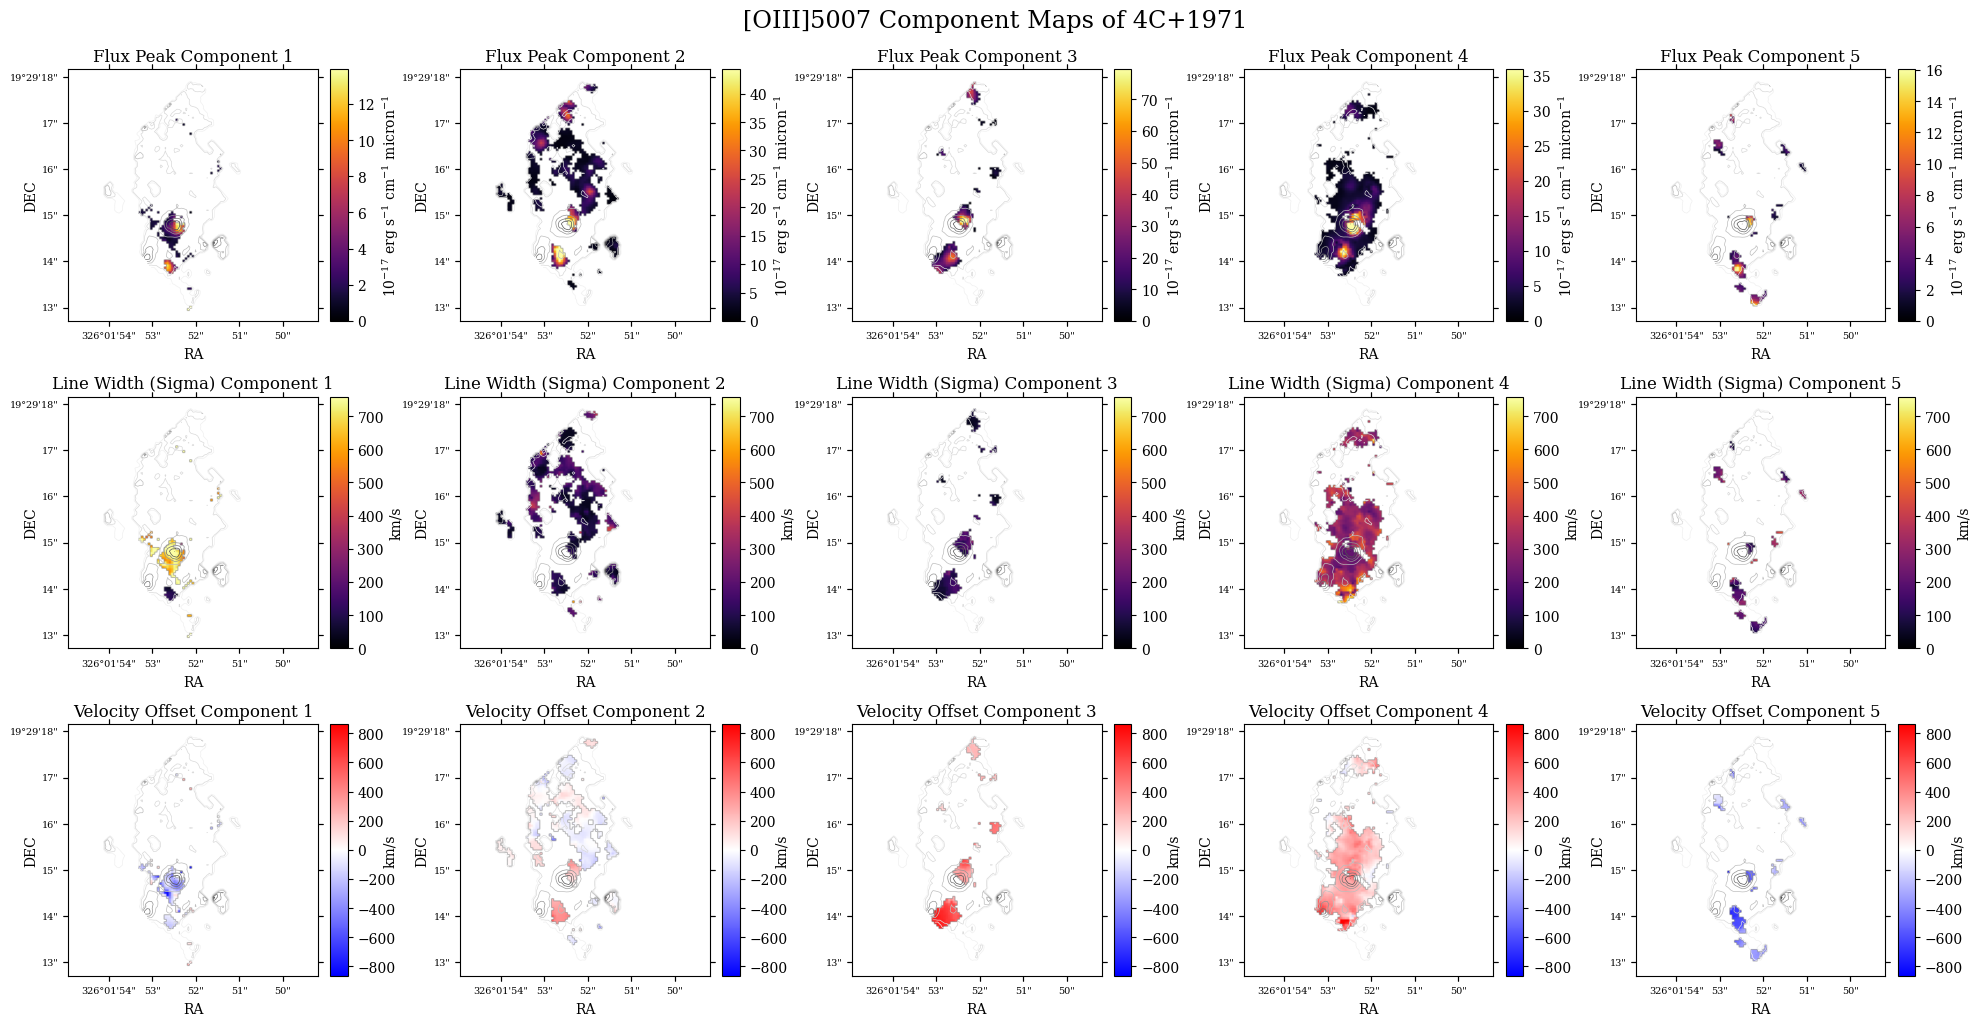

In [ ]:
def component_maps(line, file, snr_cut=0., plot_flux=True, plot_sigma=True, plot_wave=True, disable_ticks=True, percentile_limit=98, colormap="inferno", diverging_colormap="bwr"):
    contmap = np.load("contmap.npy")
    line_wavelength = list(linelist([line])["lines"])[0]
    line_data = np.load(file, allow_pickle=True)
    emlflx = line_data['emlflx'].item()
    emlflxerr = line_data['emlflxerr'].item()
    emlsig = line_data['emlsig'].item()
    emlwav = line_data['emlwav'].item()
    emlncomp = line_data['emlncomp'].item()
    # if snr_cut:
    #     cont_data = np.load(file.split(".")[0] + ".cont.npy", allow_pickle=True).item()
    #     cont = cont_data["norm_sub"]
    #     cont[cont==0.] = np.nan
    #     cont[cont>30.] = np.nan
    #     noise = np.nanstd(cont, axis=2)
    ncomp = int(np.nanmax(emlncomp[line]))
    plot_rows = int(plot_flux) + int(plot_sigma) + int(plot_wave)
    fig, axs = plt.subplots(plot_rows, ncomp, figsize=(20,3.5*plot_rows), subplot_kw={"projection": wcs_out})
    if plot_rows == 1:
        axs = axs[None]
    fluxpeak_list = []
    flux_list = []
    fluxerr_list = []
    sigma_list = []
    velocity_list = []
    lim_list = []

    for i in range(ncomp):
        mask = (emlsig[f"c{i+1}"][line] == 0.)
        emlflx[f"fc{i+1}pk"][line][mask] = np.nan
        emlflx[f"fc{i+1}"][line][mask] = np.nan
        emlflxerr[f"fc{i+1}"][line][mask] = np.nan
        emlsig[f"c{i+1}"][line][mask] = np.nan
        emlwav[f"c{i+1}"][line][mask] = np.nan

        fluxpeak = emlflx[f"fc{i+1}pk"][line]
        flux = emlflx[f"fc{i+1}"][line]
        fluxerr = emlflxerr[f"fc{i+1}"][line]
        sigma = emlsig[f"c{i+1}"][line]
        velocity = (emlwav[f"c{i+1}"][line]/((redshift+1)*line_wavelength) - 1) * ckms.value
        if snr_cut:
            snr = flux/fluxerr
            cut_mask = (snr < snr_cut)
            fluxpeak[cut_mask] = np.nan
            sigma[cut_mask] = np.nan
            velocity[cut_mask] = np.nan
        fluxpeak_list.append(fluxpeak)
        flux_list.append(flux)
        fluxerr_list.append(fluxerr)
        sigma_list.append(sigma)
        velocity_list.append(velocity)
        lim_list.append(np.max(np.abs(np.nanpercentile(velocity, (100-percentile_limit, percentile_limit)))))

    for i in range(ncomp):
        k=0
        if plot_flux:
            lim = np.nanpercentile(fluxpeak_list[i], percentile_limit)
            im0 = axs[k, i].imshow(align_north(fluxpeak_list[i].T), origin="lower", cmap=colormap, vmax=lim, vmin=0)
            cax0 = make_axes_locatable(axs[0, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
            cb0 = fig.colorbar(im0, cax=cax0, label="$10^{-17}$ erg s$^{-1}$ cm$^{-1}$ micron$^{-1}$")
            axs[k, i].set_title(f"Flux Peak Component {i+1}")
            k+=1
        if plot_sigma:
            lim = np.nanpercentile(np.max(sigma_list, axis=0), percentile_limit)
            im1 = axs[k, i].imshow(align_north(sigma_list[i].T), origin="lower", cmap=colormap, vmax=lim, vmin=0)
            cax1 = make_axes_locatable(axs[1, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
            cb1 = fig.colorbar(im1, cax=cax1, label="km/s")
            axs[k, i].set_title(f"Line Width (Sigma) Component {i+1}")
            k+=1
        if plot_wave:
            lim = np.max(lim_list)
            im2 = axs[k, i].imshow(align_north(velocity_list[i].T), origin="lower", cmap=diverging_colormap, vmax=lim, vmin=-lim)
            cax2 = make_axes_locatable(axs[2, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
            cb2 = fig.colorbar(im2, cax=cax2)
            cb2.set_label(label="km/s", labelpad=-9)
            axs[k, i].set_title(f"Velocity Offset Component {i+1}")
            k+=1
        for j in range(plot_rows):            
            axs[j, i].contour(align_north(contmap), cmap="Greys", zorder=10, linewidths=0.5)
            axs[j, i].set_xlim(xmin, xmax)
            axs[j, i].set_ylim(ymin, ymax)
            axs[j, i].set_xlabel("RA")
            axs[j, i].set_ylabel("DEC", labelpad=-1.5)
            axs[j, i].coords[0].set_major_formatter('dd:mm:ss')
            axs[j, i].coords[0].set_ticklabel(size=7)
            axs[j, i].coords[1].set_ticklabel(size=7)
        if disable_ticks: 
            for j in range(plot_rows):
                axs[j, i].set_xticks([])
                axs[j, i].set_yticks([])
    # fig.suptitle(f"{line} Component Maps of 4C+1971", size="xx-large")
    fig.tight_layout(w_pad=0, h_pad=0)
component_maps("[OIII]5007", "4C1971_neighbour_method.line.red.npz")

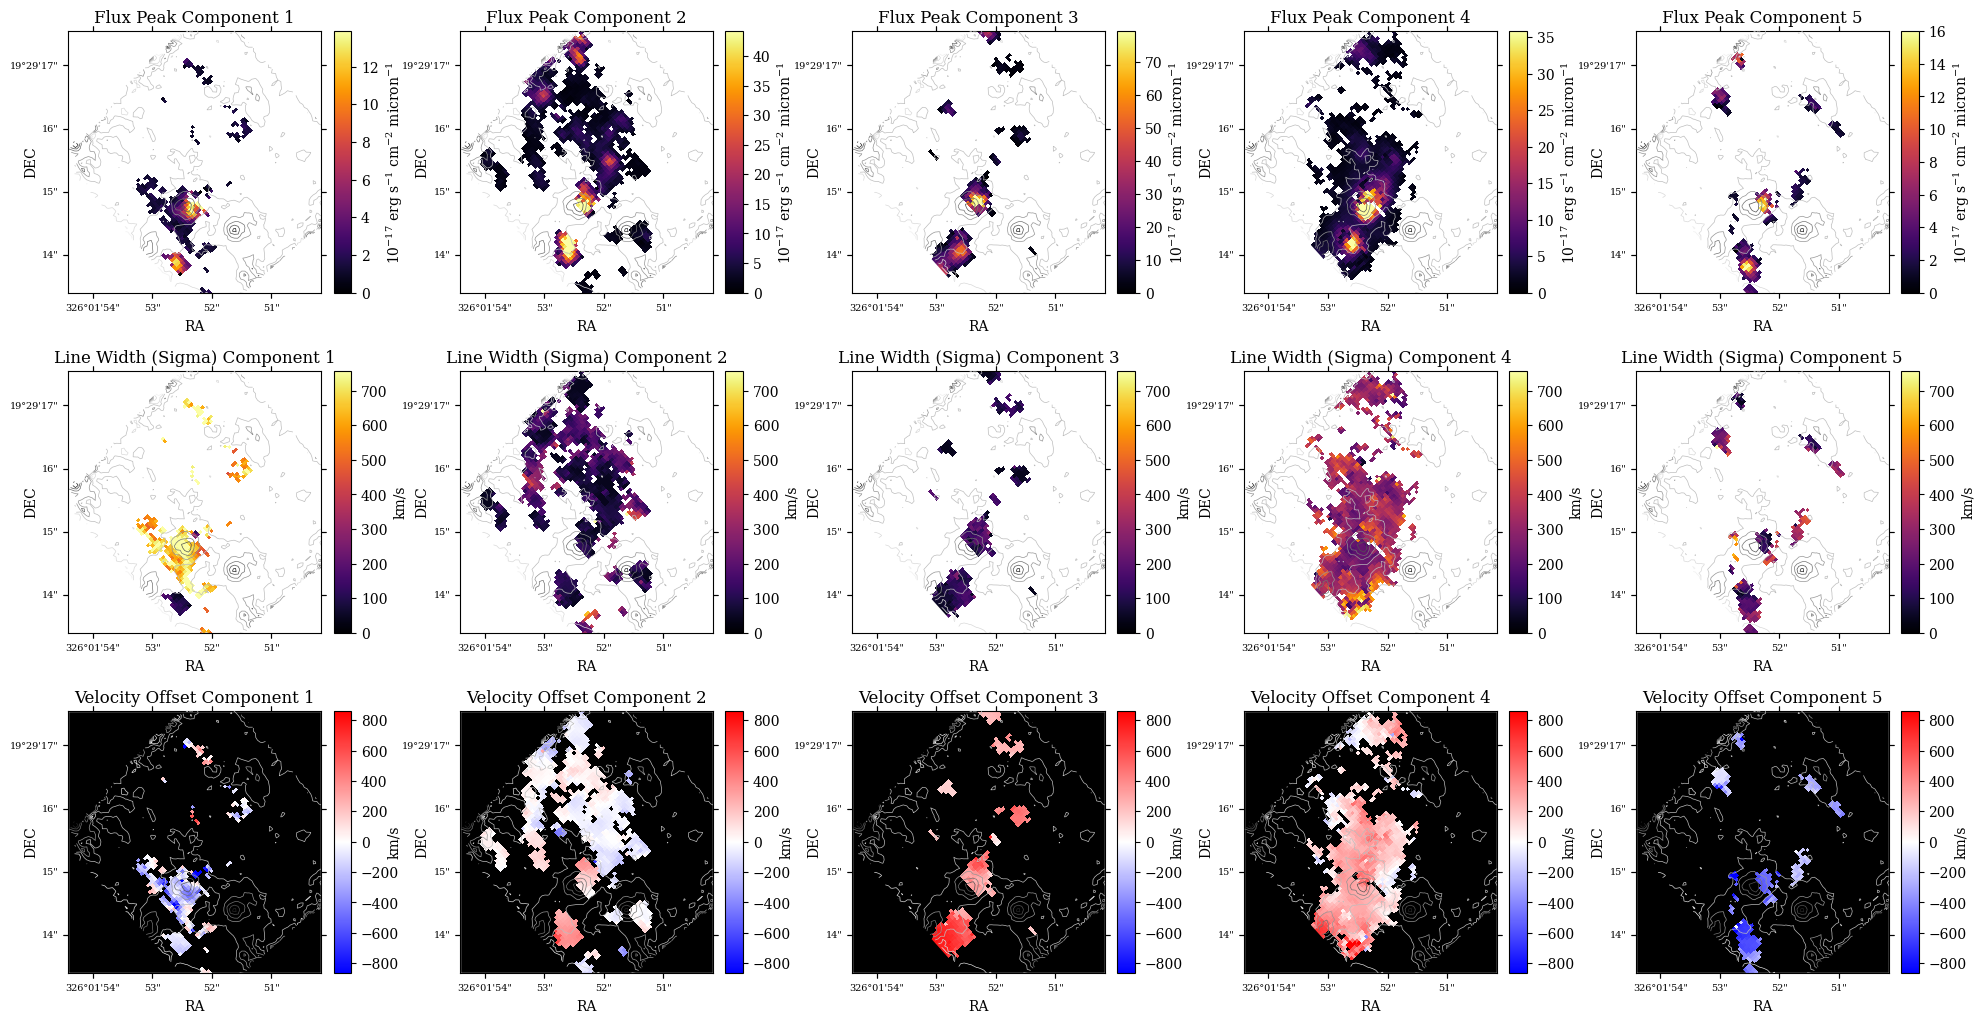

In [33]:
def component_maps_no_resampling(line, file, snr_cut=0., plot_flux=True, plot_sigma=True, plot_wave=True, disable_ticks=True, percentile_limit=98, colormap="inferno", diverging_colormap="bwr"):
    contmap = np.load("contmap.npy")
    ny, nx = contmap.shape
    line_wavelength = list(linelist([line])["lines"])[0]
    line_data = np.load(file, allow_pickle=True)
    emlflx = line_data['emlflx'].item()
    emlflxerr = line_data['emlflxerr'].item()
    emlsig = line_data['emlsig'].item()
    emlwav = line_data['emlwav'].item()
    emlncomp = line_data['emlncomp'].item()
    # if snr_cut:
    #     cont_data = np.load(file.split(".")[0] + ".cont.npy", allow_pickle=True).item()
    #     cont = cont_data["norm_sub"]
    #     cont[cont==0.] = np.nan
    #     cont[cont>30.] = np.nan
    #     noise = np.nanstd(cont, axis=2)
    cd_in = wcs.pixel_scale_matrix
    cd_out = wcs_out.pixel_scale_matrix

    R = cd_out @ np.linalg.inv(cd_in)

    angle = np.degrees(np.arctan2(R[0,1], R[1,1]))

    wcs_rot = wcs.deepcopy()

    theta = np.deg2rad(angle)

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    wcs_rot.wcs.pc = R @ wcs_rot.wcs.pc
    
    cx, cy = wcs.wcs.crpix
    rot = transforms.Affine2D().translate(-cx, -cy).rotate_deg(-angle).translate(cx, cy)
    
    ncomp = int(np.nanmax(emlncomp[line]))
    plot_rows = int(plot_flux) + int(plot_sigma) + int(plot_wave)
    fig, axs = plt.subplots(plot_rows, ncomp, figsize=(20,3.5*plot_rows), subplot_kw={"projection": wcs_rot})
    if plot_rows == 1:
        axs = axs[None]
    fluxpeak_list = []
    flux_list = []
    fluxerr_list = []
    sigma_list = []
    velocity_list = []
    lim_list = []

    for i in range(ncomp):
        mask = (emlsig[f"c{i+1}"][line] == 0.)
        emlflx[f"fc{i+1}pk"][line][mask] = np.nan
        emlflx[f"fc{i+1}"][line][mask] = np.nan
        emlflxerr[f"fc{i+1}"][line][mask] = np.nan
        emlsig[f"c{i+1}"][line][mask] = np.nan
        emlwav[f"c{i+1}"][line][mask] = np.nan

        fluxpeak = emlflx[f"fc{i+1}pk"][line]
        flux = emlflx[f"fc{i+1}"][line]
        fluxerr = emlflxerr[f"fc{i+1}"][line]
        sigma = emlsig[f"c{i+1}"][line]
        velocity = (emlwav[f"c{i+1}"][line]/((redshift+1)*line_wavelength) - 1) * ckms.value
        if snr_cut:
            snr = flux/fluxerr
            cut_mask = (snr < snr_cut)
            fluxpeak[cut_mask] = np.nan
            sigma[cut_mask] = np.nan
            velocity[cut_mask] = np.nan
        fluxpeak_list.append(fluxpeak)
        flux_list.append(flux)
        fluxerr_list.append(fluxerr)
        sigma_list.append(sigma)
        velocity_list.append(velocity)
        lim_list.append(np.max(np.abs(np.nanpercentile(velocity, (100-percentile_limit, percentile_limit)))))

    for i in range(ncomp):
        k=0
        if plot_flux:
            lim = np.nanpercentile(fluxpeak_list[i], percentile_limit)
            im0 = axs[k, i].imshow(fluxpeak_list[i].T, origin="lower", cmap=colormap, vmax=lim, vmin=0, interpolation="nearest", transform=rot+axs[k, i].get_transform("pixel"))
            cax0 = make_axes_locatable(axs[0, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
            cb0 = fig.colorbar(im0, cax=cax0, label="$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ micron$^{-1}$")
            axs[k, i].set_title(f"Flux Peak Component {i+1}")
            k+=1
        if plot_sigma:
            lim = np.nanpercentile(np.max(sigma_list, axis=0), percentile_limit)
            im1 = axs[k, i].imshow(sigma_list[i].T, origin="lower", cmap=colormap, vmax=lim, vmin=0, interpolation="nearest", transform=rot+axs[k, i].get_transform("pixel"))
            cax1 = make_axes_locatable(axs[1, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
            cb1 = fig.colorbar(im1, cax=cax1, label="km/s")
            axs[k, i].set_title(f"Line Width (Sigma) Component {i+1}")
            k+=1
        if plot_wave:
            lim = np.max(lim_list)
            im2 = axs[k, i].imshow(velocity_list[i].T, origin="lower", cmap=diverging_colormap, vmax=lim, vmin=-lim, interpolation="nearest", transform=rot+axs[k, i].get_transform("pixel"))
            cax2 = make_axes_locatable(axs[2, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
            cb2 = fig.colorbar(im2, cax=cax2)
            cb2.set_label(label="km/s", labelpad=-9)
            axs[k, i].set_title(f"Velocity Offset Component {i+1}")
            axs[k, i].set_facecolor("black")
            k+=1
        for j in range(plot_rows):            
            axs[j, i].contour(contmap, cmap="Greys", zorder=10, linewidths=0.5, transform=rot+axs[j, i].get_transform("pixel"))
            axs[j, i].set_xlim(-10, nx)
            axs[j, i].set_ylim(0, ny)
            axs[j, i].set_xlabel("RA")
            axs[j, i].set_ylabel("DEC", labelpad=-1.5)
            axs[j, i].coords[0].set_major_formatter('dd:mm:ss')
            axs[j, i].coords[0].set_ticklabel(size=7)
            axs[j, i].coords[1].set_ticklabel(size=7)
        if disable_ticks: 
            for j in range(plot_rows):
                axs[j, i].set_xticks([])
                axs[j, i].set_yticks([])
    # fig.suptitle(f"{line} Component Maps of 4C+1971", size="xx-large")
    fig.tight_layout(w_pad=0, h_pad=0)
    fig.savefig(os.path.join("plots", f"component_map_{line}.pdf"))
component_maps_no_resampling("[OIII]5007", "4C1971_neighbour_method.line.red.npz")

In [18]:
# data = np.load("output_Halpha/4C1971_other_lines_Halpha.cont.npy", allow_pickle=True).item()
# y = data['dat'][24,36]
# x = np.arange(3815)
# plt.plot(x[y!=0], y[y!=0])
# plt.hlines((np.std(y[y!=0])), 3250, 3550)
# data.keys()

In [17]:
# dat = np.load("4C1971_neighbour_method.line.red.npz", allow_pickle=True)
# for k in dat:
#     print(k)
# dat["emlflxerr"].item().keys()

In [16]:
# y = data["norm_sub"][1,30]
# y[y>30.] = 0.
# x = np.arange(3815)
# plt.plot(x[y!=0], y[y!=0])
# plt.hlines((np.nanstd(y[y!=0]),0,-np.nanstd(y[y!=0])), 3250, 3550)
# np.nanstd(y[y!=0])

In [15]:
# cont = data["norm_sub"]
# cont[cont==0.] = np.nan
# cont[cont>30.] = np.nan
# std = np.nanstd(cont, axis=2).T
# vmin, vmax = np.nanpercentile(std, (2, 98))
# plt.imshow(std, origin="lower", vmin=vmin, vmax=vmax)
# plt.colorbar()
# plt.show()

In [29]:
# component_maps("Hbeta", "4C1971_neighbour_method.line.red.npz", plot_sigma=False, plot_wave=False)
# component_maps("Hbeta", "4C1971_neighbour_method.line.red.npz", snr_cut=3., plot_sigma=False, plot_wave=False)

In [28]:
# component_maps("Halpha", "output_Halpha/4C1971_other_lines_Halpha.line.npz", snr_cut=0., plot_sigma=False, plot_wave=False)
# component_maps("Halpha", "output_Halpha/4C1971_other_lines_Halpha.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)
# component_maps("[NII]6548", "output_Halpha/4C1971_other_lines_Halpha.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)
# component_maps("[NII]6583", "output_Halpha/4C1971_other_lines_Halpha.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)

In [27]:
# component_maps("[OII]3726", "output_OII/4C1971_other_lines_OII.line.npz", plot_sigma=False, plot_wave=False)
# component_maps("[OII]3726", "output_OII/4C1971_other_lines_OII.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)
# component_maps("[OII]3729", "output_OII/4C1971_other_lines_OII.line.npz", plot_sigma=False, plot_wave=False)
# component_maps("[OII]3729", "output_OII/4C1971_other_lines_OII.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)

In [26]:
# component_maps("[OII]3726", "output_OII2/4C1971_other_lines_OII2.line.npz", plot_sigma=False, plot_wave=False)
# component_maps("[OII]3726", "output_OII2/4C1971_other_lines_OII2.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)

In [25]:
# component_maps("[SII]6716", "output_SII/4C1971_other_lines_SII.line.npz", plot_sigma=False, plot_wave=False)
# component_maps("[SII]6716", "output_SII/4C1971_other_lines_SII.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)
# component_maps("[SII]6731", "output_SII/4C1971_other_lines_SII.line.npz", plot_sigma=False, plot_wave=False)
# component_maps("[SII]6731", "output_SII/4C1971_other_lines_SII.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)

In [24]:
# component_maps("[NeIII]3869", "output_NeIII/4C1971_other_lines_NeIII.line.npz", plot_sigma=False, plot_wave=False)
# component_maps("[NeIII]3869", "output_NeIII/4C1971_other_lines_NeIII.line.npz", snr_cut=3., plot_sigma=False, plot_wave=False)

In [392]:
def bpt(snr_cut):
    np.seterr(all='ignore')
    OIII_file = "4C1971_neighbour_method.line.red.npz"
    Halpha_file = "output_Halpha/4C1971_other_lines_Halpha.line.npz"
    OIII_line_data = np.load(OIII_file, allow_pickle=True)
    Halpha_line_data = np.load(Halpha_file, allow_pickle=True)
    OIII_flx = OIII_line_data['emlflx'].item()
    OIII_flx_err = OIII_line_data['emlflxerr'].item()
    emlsig = OIII_line_data['emlsig'].item()
    Halpha_flx = Halpha_line_data['emlflx'].item()
    Halpha_flx_err = Halpha_line_data['emlflxerr'].item()
    emlncomp = OIII_line_data['emlncomp'].item()

    # def get_noise(file):
    #     cont_data = np.load(file.split(".")[0] + ".cont.npy", allow_pickle=True).item()
    #     cont = cont_data["norm_sub"]
    #     cont[cont==0.] = np.nan
    #     cont[cont>30.] = np.nan
    #     noise = np.nanstd(cont, axis=2)
    #     return noise
    # if snr_cut:
    #     OIII_noise = get_noise(OIII_file)
    #     Halpha_noise = get_noise(Halpha_file)
        
    ncomp = int(np.nanmax(emlncomp["[OIII]5007"]))
    # fig, axs = plt.subplots(3, ncomp, figsize=(20,12))
    fig = plt.figure(figsize=(20,9))
    plots_shape = (3, ncomp)
    axs = np.empty(plots_shape, dtype=object)
    for i in range(ncomp):
        axs[0, i] = fig.add_subplot(*plots_shape, i+1, projection=wcs_out)
        axs[1, i] = fig.add_subplot(*plots_shape, ncomp+i+1, projection=wcs_out)
        axs[2, i] = fig.add_subplot(*plots_shape, 2*ncomp+i+1)

    fig.tight_layout(w_pad=0, h_pad=0)

    for i in range(ncomp):
        # ignore spaxels without linefit
        mask = (emlsig[f"c{i+1}"]["[OIII]5007"] == 0.)
        OIII_flx[f"fc{i+1}"]["[OIII]5007"][mask] = np.nan
        OIII_flx[f"fc{i+1}"]["Hbeta"][mask] = np.nan
        Halpha_flx[f"fc{i+1}"]["Halpha"][mask] = np.nan
        Halpha_flx[f"fc{i+1}"]["[NII]6583"][mask] = np.nan
        OIII_flx_err[f"fc{i+1}"]["[OIII]5007"][mask] = np.nan
        OIII_flx_err[f"fc{i+1}"]["Hbeta"][mask] = np.nan
        Halpha_flx_err[f"fc{i+1}"]["Halpha"][mask] = np.nan
        Halpha_flx_err[f"fc{i+1}"]["[NII]6583"][mask] = np.nan

        if snr_cut:
            snr_OIII = OIII_flx[f"fc{i+1}"]["[OIII]5007"]/OIII_flx_err[f"fc{i+1}"]["[OIII]5007"]
            snr_Hbeta = OIII_flx[f"fc{i+1}"]["Hbeta"]/OIII_flx_err[f"fc{i+1}"]["Hbeta"]
            snr_Halpha = Halpha_flx[f"fc{i+1}"]["Halpha"]/Halpha_flx_err[f"fc{i+1}"]["Halpha"]
            snr_NII = Halpha_flx[f"fc{i+1}"]["[NII]6583"]/Halpha_flx_err[f"fc{i+1}"]["[NII]6583"]

            # OIII_flx[f"fc{i+1}"]["[OIII]5007"][snr_OIII < snr_cut] = np.nan
            # # OIII_flx[f"fc{i+1}"]["Hbeta"][snr_Hbeta < snr_cut] = np.nan
            # Halpha_flx[f"fc{i+1}"]["Halpha"][snr_Halpha < snr_cut] = np.nan
            # Halpha_flx[f"fc{i+1}"]["[NII]6583"][snr_NII < snr_cut] = np.nan

            # mask_Hbeta = OIII_flx[f"fc{i+1}pk"]["Hbeta"]<(OIII_noise*snr_cut)
            # OIII_flx[f"fc{i+1}"]["Hbeta"][mask_Hbeta] = np.nan
            # OIII_flx[f"fc{i+1}"]["[OIII]5007"][OIII_flx[f"fc{i+1}pk"]["[OIII]5007"]<OIII_noise*snr_cut] = np.nan
            # Halpha_flx[f"fc{i+1}"]["Halpha"][Halpha_flx[f"fc{i+1}pk"]["Halpha"]<Halpha_noise*snr_cut] = np.nan
            # Halpha_flx[f"fc{i+1}"]["[NII]6583"][Halpha_flx[f"fc{i+1}pk"]["[NII]6583"]<Halpha_noise*snr_cut] = np.nan

            # OIII_flx[f"fc{i+1}"]["Hbeta"][mask_Hbeta] = OIII_noise[mask_Hbeta]*snr_cut
            OIII_flx[f"fc{i+1}"]["Hbeta"] = np.where(snr_Hbeta > snr_cut, OIII_flx[f"fc{i+1}"]["Hbeta"], OIII_flx_err[f"fc{i+1}"]["Hbeta"]*snr_cut)
            lower_limit = np.where(snr_Halpha > snr_cut, 0, 1)
            # OIIIoverHbeta_lim = np.log10(OIII_flx[f"fc{i+1}"]["[OIII]5007"]/OIII_flx[f"fc{i+1}"]["Hbeta"])
            # NIIoverHalpha_lim = np.log10(Halpha_flx[f"fc{i+1}"]["[NII]6583"]/Halpha_flx[f"fc{i+1}"]["Halpha"])

        OIIIoverHbeta = np.log10(OIII_flx[f"fc{i+1}"]["[OIII]5007"]/OIII_flx[f"fc{i+1}"]["Hbeta"])
        NIIoverHalpha = np.log10(Halpha_flx[f"fc{i+1}"]["[NII]6583"]/Halpha_flx[f"fc{i+1}"]["Halpha"])

        lim = np.nanpercentile(OIIIoverHbeta, percentile_limit)
        im0 = axs[0, i].imshow(align_north(OIIIoverHbeta.T), origin="lower", vmax=2.5, vmin=-1)
        cax0 = make_axes_locatable(axs[0, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
        cb0 = fig.colorbar(im0, cax=cax0, label="log([OIII]/Hb)")
        axs[0, i].set_title(f"Component {i+1}")
        # y, x = np.where(align_north((OIIIoverHbeta < (0.61 / (NIIoverHalpha - 0.05) + 1.3)).T))
        # axs[0, i].scatter(x, y, marker=".", s=1)
        
        lim = np.nanpercentile(NIIoverHalpha, percentile_limit)
        im0 = axs[1, i].imshow(align_north(NIIoverHalpha.T), origin="lower", vmax=-2, vmin=2)
        cax0 = make_axes_locatable(axs[1, i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
        cb0 = fig.colorbar(im0, cax=cax0, label="log([NII]/Ha)")
        axs[1, i].set_title(f"Component {i+1}")

        axs[0, i].imshow(align_north(np.where(np.isfinite(OIIIoverHbeta.T), np.where((OIIIoverHbeta < (0.61 / (NIIoverHalpha - 0.05) + 1.3)).T, 5, np.nan), np.nan)), origin="lower", cmap=diverging_colormap, vmax=2.5, vmin=-1)
        axs[1, i].imshow(align_north(np.where(np.isfinite(NIIoverHalpha.T), np.where((OIIIoverHbeta < (0.61 / (NIIoverHalpha - 0.05) + 1.3)).T, 5, np.nan), np.nan)), origin="lower", cmap=diverging_colormap, vmax=2.5, vmin=-1)
        # axs[1, i].imshow(align_north(np.where((NIIoverHalpha.T > -5) & (NIIoverHalpha.T < 5), np.where((OIIIoverHbeta < (0.61 / (NIIoverHalpha - 0.05) + 1.3)).T, 5, np.nan), np.nan)), origin="lower", cmap=diverging_colormap, vmax=2.5, vmin=-1)
        
        for j in (0, 1):
            axs[j, i].set_xlim(xmin, xmax)
            axs[j, i].set_ylim(ymin, ymax)
            axs[j, i].set_xlabel("RA")
            axs[j, i].set_ylabel("DEC", labelpad=-1.5)
            axs[j, i].coords[0].set_major_formatter('dd:mm:ss')
            axs[j, i].coords[0].set_ticklabel(size=7)
            axs[j, i].coords[1].set_ticklabel(size=7)

        axs[2, i].scatter(NIIoverHalpha.flatten(), OIIIoverHbeta.flatten(), marker=".", color="gray", alpha=0.5)
        if snr_cut:
            axs[2, i].errorbar(NIIoverHalpha.flatten(), OIIIoverHbeta.flatten(), xerr=0, yerr=0.1*lower_limit.flatten(), lolims=lower_limit.flatten(), linestyle='none', fmt="none", elinewidth=1, capsize=1, alpha=0.5)
        x1 = np.linspace(-2, 0.049, 100)
        x2 = np.linspace(-2, 0.469, 100)
        y1 = 0.61 / (x1 - 0.05) + 1.3
        y2 = 0.61 / (x2 - 0.47) + 1.19 
        axs[2, i].plot(x1,y1)  # Kauffmann+03
        axs[2, i].plot(x2,y2)  # Kewley+01
        axs[2, i].set_xlim(-2,2)
        axs[2, i].set_ylim(-1,2.5)
        axs[2, i].set_xlabel("log([NII]/Ha)")
        axs[2, i].set_ylabel("log([OIII]/Hb)")
        
        plt.figure(figsize=(9,9))
        ax = plt.gca()
        ax.scatter(NIIoverHalpha.flatten(), OIIIoverHbeta.flatten(), marker=".", color="gray", alpha=0.5)
        if snr_cut:
            ax.errorbar(NIIoverHalpha.flatten(), OIIIoverHbeta.flatten(), xerr=0, yerr=0.05*lower_limit.flatten(), lolims=lower_limit.flatten(), linestyle='none', fmt="none", elinewidth=1, capsize=1, alpha=0.5)
        ax.plot(x1,y1)  # Kauffmann+03
        ax.plot(x2,y2)  # Kewley+01
        ax.set_xlim(-2,2)
        ax.set_ylim(-1,2.5)
        ax.set_xlabel("log([NII]/Ha)")
        ax.set_ylabel("log([OIII]/Hb)")
        ax.set_title(f"BPT comp {i+1}, {snr_cut = }")
    plt.show()

In [30]:
# bpt(2.)

In [31]:
# bpt(0.)

In [23]:
# binned_map = np.load("binned_map.npy")
# seedpixels = np.load("colsrows.npy")
# plt.figure(figsize=(8,8))
# plt.imshow(binned_map.T, origin="lower")
# plt.scatter(*seedpixels, s=3, marker="x", color="purple")

# binned_map_2 = np.load("binned_map_2.npy")
# seedpixels_2 = np.load("colsrows_2.npy")
# plt.figure(figsize=(8,8))
# plt.imshow(binned_map_2.T, origin="lower")
# plt.scatter(*seedpixels_2, s=3, marker="x", color="purple")

In [7]:
binned_map = np.load("binned_map.npy")
seedpixels = np.load("colsrows.npy")
# plt.figure(figsize=(8,8))
# plt.imshow(binned_map.T, origin="lower")
# plt.scatter(*seedpixels, s=3, marker="x", color="purple")

def reverse_bin(arr: np.ndarray) -> np.ndarray:
    new_array = np.nan * np.ones_like(binned_map)
    for i, (x, y) in enumerate(seedpixels.T):
        assert i == binned_map[x, y]
        new_array[binned_map==i] = arr[x, y]
    return new_array

binned_map_2 = np.load("binned_map_2.npy")
seedpixels_2 = np.load("colsrows_2.npy")

def reverse_bin_2(arr: np.ndarray) -> np.ndarray:
    new_array = np.nan * np.ones_like(binned_map_2)
    for i, (x, y) in enumerate(seedpixels_2.T):
        assert i == binned_map_2[x, y], f"{i=}, {x=}, {y=}, {binned_map_2[x,y]=}"
        new_array[binned_map_2==i] = arr[x, y]
    return new_array

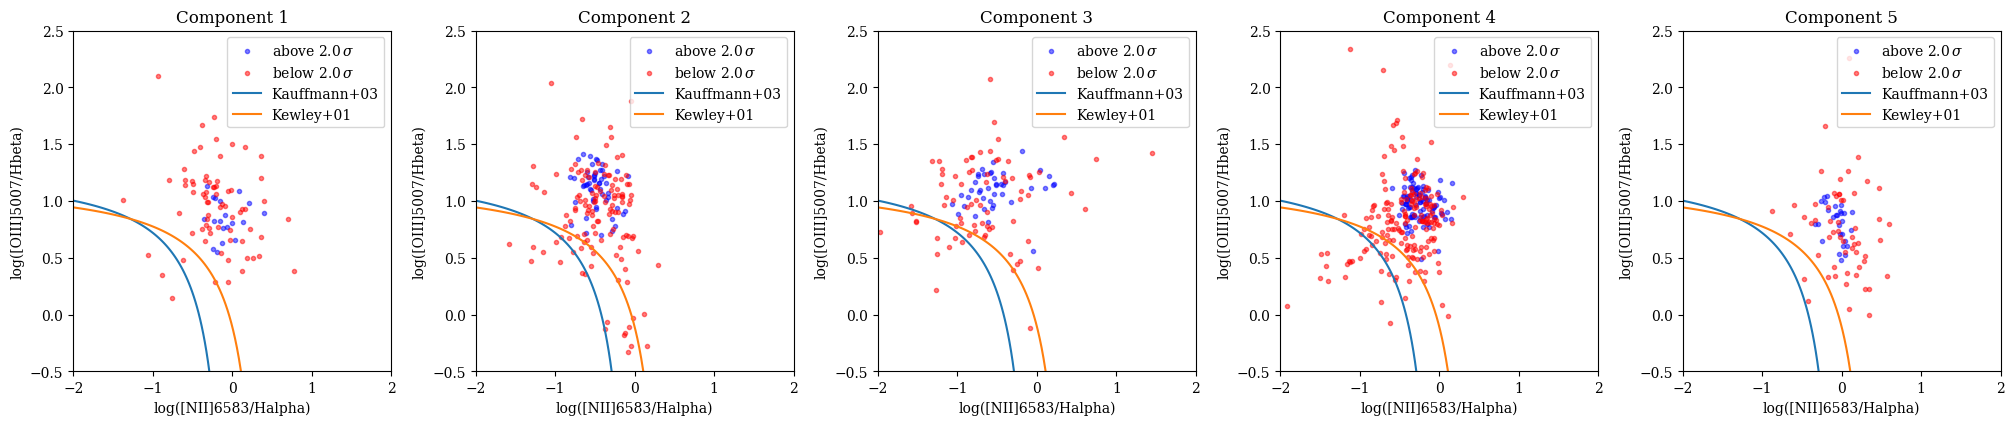

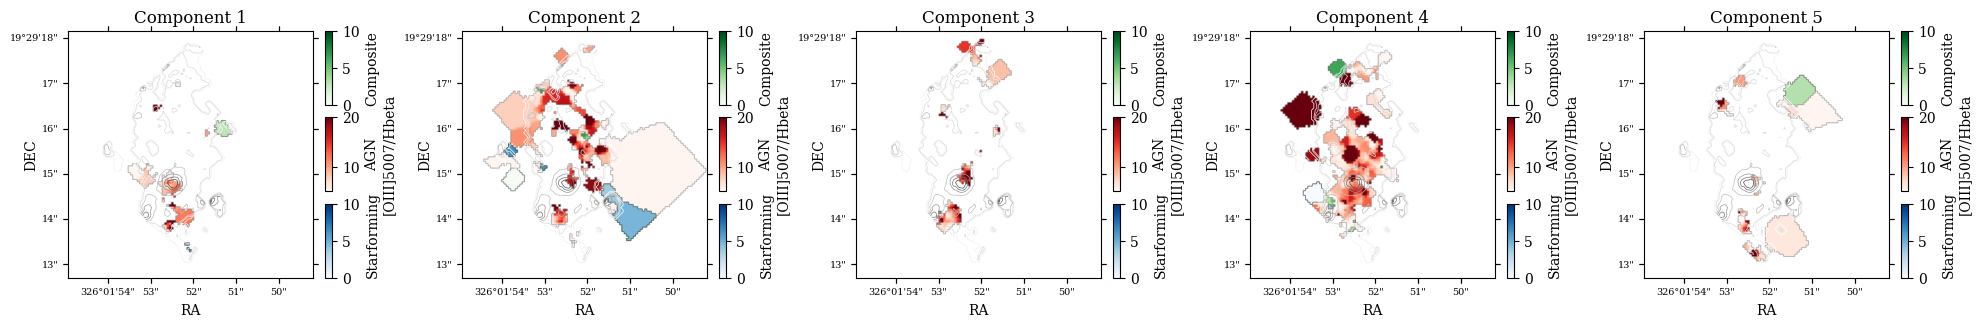

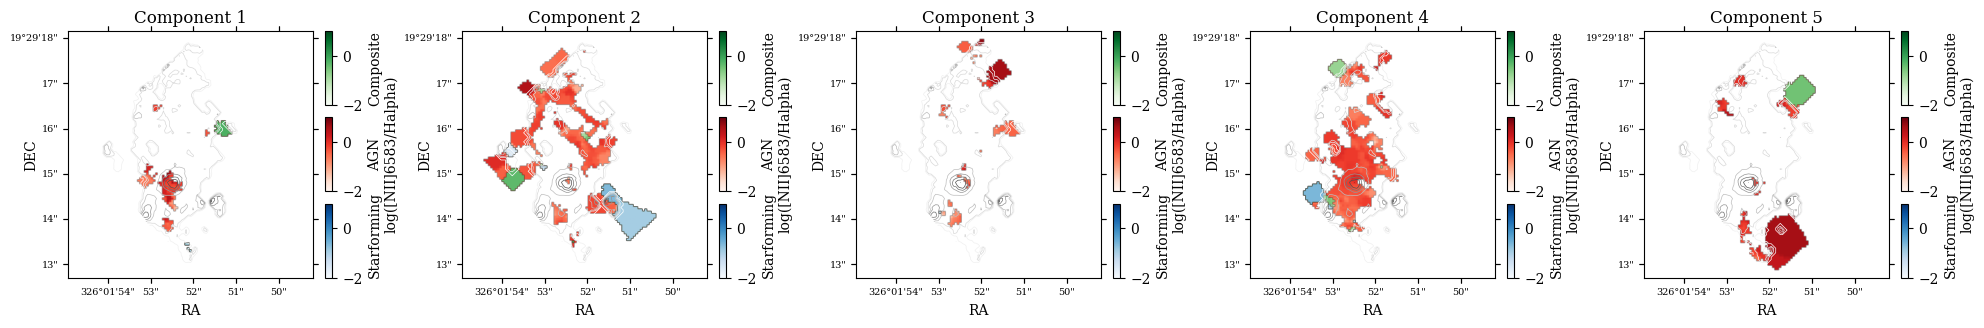

In [24]:
def bpt_diagram(
        snr_cut,
        line1, file1,
        line2, file2,
        line3, file3,
        line4, file4,
        *lines
):
    "plot bpt diagram 1/2 (y-axis) vs 3/4 (x-axis)"
    np.seterr(all='ignore')

    contmap = np.load("contmap.npy")
    
    def get_data(file):
        file_data = np.load(file, allow_pickle=True)
        line_flux = file_data["emlflx"].item()
        line_fluxerr = file_data["emlflxerr"].item()
        line_sigma = file_data['emlsig'].item()
        line_ncomp = file_data['emlncomp'].item()
        return line_flux, line_fluxerr, line_sigma, line_ncomp
    
    # line1_flux, line1_fluxerr, line1_sigma, line1_ncomp = get_data(file1)
    # line2_flux, line2_fluxerr, line2_sigma, line2_ncomp = get_data(file2)
    # line3_flux, line3_fluxerr, line3_sigma, line3_ncomp = get_data(file3)
    # line4_flux, line4_fluxerr, line4_sigma, line4_ncomp = get_data(file4)

    line_list = [line1, line2, line3, line4]
    flux_list, fluxerr_list, sigma_list, ncomp_list = list(zip(get_data(file1), get_data(file2), get_data(file3), get_data(file4)))

    ncomp = np.max([int(np.nanmax(n[l])) for n, l in zip(ncomp_list, line_list)])
    fig, axs = plt.subplots(1, ncomp, figsize=(20,4))
    fig2, axs2 = plt.subplots(1, ncomp, figsize=(20,4), subplot_kw={"projection": wcs_out})
    fig3, axs3 = plt.subplots(1, ncomp, figsize=(20,4), subplot_kw={"projection": wcs_out})
    fig.tight_layout(w_pad=3, h_pad=0)
    # fig2.tight_layout(w_pad=5, h_pad=0)
    fig2.tight_layout(w_pad=0, h_pad=0)
    # fig3.tight_layout(w_pad=5, h_pad=0)
    fig3.tight_layout(w_pad=0, h_pad=0)

    for i in range(ncomp):
        # ignore spaxels without linefit
        for line, flux, fluxerr, sigma in zip(line_list, flux_list, fluxerr_list, sigma_list):
            mask = (sigma[f"c{i+1}"][line] == 0.)
            flux[f"fc{i+1}"][line][mask] = np.nan
            fluxerr[f"fc{i+1}"][line][mask] = np.nan

        above_cut = np.ones_like(flux_list[0][f"fc{i+1}"][line_list[0]], dtype=bool)
        for line, flux, fluxerr in zip(line_list, flux_list, fluxerr_list):
            snr = flux[f"fc{i+1}"][line] / fluxerr[f"fc{i+1}"][line]
            # if snr_cut:
            #     flux[f"fc{i+1}"][line][snr < snr_cut] = np.nan
            above_cut *= (snr > snr_cut)
        flux0 = flux_list[0][f"fc{i+1}"][line_list[0]]
        flux1 = flux_list[1][f"fc{i+1}"][line_list[1]]
        flux2 = flux_list[2][f"fc{i+1}"][line_list[2]]
        flux3 = flux_list[3][f"fc{i+1}"][line_list[3]]
        y_data = np.log10(np.where(flux0 > 0.0001, flux0, np.nan) / np.where(flux1 > 0.0001, flux1, np.nan))
        x_data = np.log10(np.where(flux2 > 0.0001, flux2, np.nan) / np.where(flux3 > 0.0001, flux3, np.nan))
        # y_data = np.log10(flux_list[0][f"fc{i+1}"][line_list[0]] / flux_list[1][f"fc{i+1}"][line_list[1]])
        # x_data = np.log10(flux_list[2][f"fc{i+1}"][line_list[2]] / flux_list[3][f"fc{i+1}"][line_list[3]])

        # below_Ka03 = (y_data < 0.61 / (x_data - 0.05) + 1.3)
        # below_Ka03[x_data > 0.05] = False
        # below_Ke01 = (y_data < 0.61 / (x_data - 0.47) + 1.19)
        # below_Ke01[x_data > 0.47] = False
        # below_line = np.logical_or(below_Ka03, below_Ke01)

        below_list = []
        for l in lines:
            below_l = y_data < l(x_data)
            if isinstance(l, AGNLine):
                below_l[x_data > -l.v2] = False
            below_list.append(below_l)
        if len(below_list) == 2:
            below_line = np.logical_or(*below_list)
        elif len(below_list) == 1:
            below_line = below_list[0]
        elif len(below_list) == 0:
            below_line = np.zeros_like(x_data, dtype=bool)
        else:
            raise NotImplementedError("2 lines max")


        # axs[i].scatter(x_data[below_line].flatten(), y_data[below_line].flatten(), c="black", marker="x", alpha=0.5, label="below line")
        axs[i].scatter(x_data[above_cut].flatten(), y_data[above_cut].flatten(), c="blue", marker=".", alpha=0.5, label=f"above {snr_cut}$\\,\\sigma$")
        axs[i].scatter(x_data[~above_cut].flatten(), y_data[~above_cut].flatten(), c="red", marker=".", alpha=0.5, label=f"below {snr_cut}$\\,\\sigma$")
        # axs[i].scatter(x_data.flatten(), y_data.flatten(), c=~above_cut.flatten(), cmap="bwr", marker=".", alpha=0.5)
        # x1 = np.linspace(-2, -0.08, 100)
        # x2 = np.linspace(-2, 0.34, 100)
        # axs[i].plot(x1, 0.61 / (x1 - 0.05) + 1.3, label="Kauffmann+03")  # Kauffmann+03
        # axs[i].plot(x2, 0.61 / (x2 - 0.47) + 1.19, label="Kewley+01")  # Kewley+01
        for l in lines:
            if isinstance(l, AGNLine):
                x = np.linspace(-2, -l.v2-0.1, 100)
                axs[i].plot(x, l(x), label=l.label)
            else:
                y1 = lines[0].v1
                y2 = lines[0].v2
                y3 = lines[0].v3
                x1 = lines[1].v1
                x2 = lines[1].v2
                A = (-(x1*y2+x2-y3)-np.sqrt((x1*y2+x2-y3)**2-4*x1*(y2*x2-y2*y3-y1)))/(2*x1)
                # print(A)
                x_ = np.linspace(A, 2, 100)
                axs[i].plot(x_, l(x_), label=l.label)
        axs[i].set_xlim(-2,2)
        axs[i].set_ylim(-0.5,2.5)
        axs[i].set_ylabel(f"log({line_list[0]}/{line_list[1]})")
        axs[i].set_xlabel(f"log({line_list[2]}/{line_list[3]})")
        axs[i].legend()
        axs[i].set_title(f"Component {i+1}")

        ################
        below_line[~np.isfinite(x_data)] = False
        below_line[~np.isfinite(y_data)] = False

        ### axs2 ###
        data = y_data
        im_agn = axs2[i].imshow(align_north(reverse_bin(10**data).T), origin="lower", vmax=20, vmin=5, cmap="Reds")
        im_comp = axs2[i].imshow(align_north(reverse_bin(np.where(below_list[1], 10*data, np.nan)).T), origin="lower", vmax=10, vmin=0, cmap="Greens")
        im_sf = axs2[i].imshow(align_north(reverse_bin(np.where(below_list[0], 10*data, np.nan)).T), origin="lower", vmax=10, vmin=0, cmap="Blues")
        axs2[i].contour(align_north(contmap), cmap="Greys", zorder=10, linewidths=0.5)
        cb_height = 0.3
        spacing = 0.05
        cax1 = inset_axes(axs2[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, 2*(cb_height + spacing), 1, 1), bbox_transform=axs2[i].transAxes, borderpad=0)
        cax2 = inset_axes(axs2[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, cb_height + spacing, 1, 1), bbox_transform=axs2[i].transAxes, borderpad=0)
        cax3 = inset_axes(axs2[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, 0.0, 1, 1), bbox_transform=axs2[i].transAxes, borderpad=0)
        
        cb1 = fig2.colorbar(im_comp, cax=cax1)
        cb2 = fig2.colorbar(im_agn, cax=cax2)
        cb3 = fig2.colorbar(im_sf, cax=cax3)
        if isinstance(lines[1], AGNLine):
            cb1.set_label("Composite", loc="top")
            cb2.set_label(f"AGN\n{line_list[0]}/{line_list[1]}", loc="center")
            cb3.set_label("Starforming", loc="bottom")
        else:
            cb1.set_label("LINER", loc="top")
            cb2.set_label(f"Syfert\n{line_list[0]}/{line_list[1]}", loc="center")
            cb3.set_label("Starforming", loc="bottom")

        zoom_in = False
        a = 20 if zoom_in else 0
        b = 30 if zoom_in else 0
        c = 15 if zoom_in else 0
        d = 20 if zoom_in else 0
        
        axs2[i].set_title(f"Component {i+1}")
        axs2[i].set_xlim(xmin+a, xmax-b)
        axs2[i].set_ylim(ymin+c, ymax-d)
        axs2[i].set_xlabel("RA")
        axs2[i].set_ylabel("DEC", labelpad=-1.5)
        axs2[i].coords[0].set_major_formatter('dd:mm:ss')
        axs2[i].coords[0].set_ticklabel(size=7)
        axs2[i].coords[1].set_ticklabel(size=7)
        ### ax3 ###
        data = x_data
        im_agn = axs3[i].imshow(align_north(reverse_bin(data).T), origin="lower", vmax=1, vmin=-2, cmap="Reds")
        im_comp = axs3[i].imshow(align_north(reverse_bin(np.where(below_list[1], data, np.nan)).T), origin="lower", vmax=1, vmin=-2, cmap="Greens")
        im_sf = axs3[i].imshow(align_north(reverse_bin(np.where(below_list[0], data, np.nan)).T), origin="lower", vmax=1, vmin=-2, cmap="Blues")
        axs3[i].contour(align_north(contmap), cmap="Greys", zorder=10, linewidths=0.5)
        cb_height = 0.3
        spacing = 0.05
        cax1 = inset_axes(axs3[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, 2*(cb_height + spacing), 1, 1), bbox_transform=axs3[i].transAxes, borderpad=0)
        cax2 = inset_axes(axs3[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, cb_height + spacing, 1, 1), bbox_transform=axs3[i].transAxes, borderpad=0)
        cax3 = inset_axes(axs3[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, 0.0, 1, 1), bbox_transform=axs3[i].transAxes, borderpad=0)
        
        cb1 = fig3.colorbar(im_comp, cax=cax1)
        cb2 = fig3.colorbar(im_agn, cax=cax2)
        cb3 = fig3.colorbar(im_sf, cax=cax3)
        if isinstance(lines[1], AGNLine):
            cb1.set_label("Composite", loc="top")
            cb2.set_label(f"AGN\nlog({line_list[2]}/{line_list[3]})", loc="center")
            cb3.set_label("Starforming", loc="bottom")
        else:
            cb1.set_label("LINER", loc="top")
            cb2.set_label(f"Syfert\nlog({line_list[2]}/{line_list[3]})", loc="center")
            cb3.set_label("Starforming", loc="bottom")

        axs3[i].set_title(f"Component {i+1}")
        axs3[i].set_xlim(xmin+a, xmax-b)
        axs3[i].set_ylim(ymin+c, ymax-d)
        axs3[i].set_xlabel("RA")
        axs3[i].set_ylabel("DEC", labelpad=-1.5)
        axs3[i].coords[0].set_major_formatter('dd:mm:ss')
        axs3[i].coords[0].set_ticklabel(size=7)
        axs3[i].coords[1].set_ticklabel(size=7)

        # im0 = axs2[i].imshow(align_north(x_data.T), origin="lower", vmax=2, vmin=-2)
        # axs2[i].imshow(align_north(np.where(below_line, 1, np.nan).T), origin="lower", cmap="bwr", vmin=0, vmax=1)
        # cax0 = make_axes_locatable(axs2[i]).append_axes("right", size="7%", pad="5%", axes_class = Axes)
        # cb0 = fig2.colorbar(im0, cax=cax0, label=f"log({line_list[2]}/{line_list[3]})")

# def kauffmann_line(data):
#     return 0.61 / (data - 0.05) + 1.3
# def kewley_line(data):
#     return 0.61 / (data - 0.47) + 1.19
class AGNLine:
    def __init__(self, v1, v2, v3, label):
        self.v1 = v1
        self.v2 = v2
        self.v3 = v3
        self.label = label
    def __call__(self, data):
        return self.v1 / (data + self.v2) + self.v3
kauffmann_line = AGNLine(0.61, -0.05, 1.3, "Kauffmann+03")
kewley_line = AGNLine(0.61, -0.47, 1.19, "Kewley+01")

bpt_diagram(2.,
            "[OIII]5007", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "[NII]6583", "Halpha/output_from_OIII_binned/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned/4C1971.line.npz",
            kauffmann_line, kewley_line)

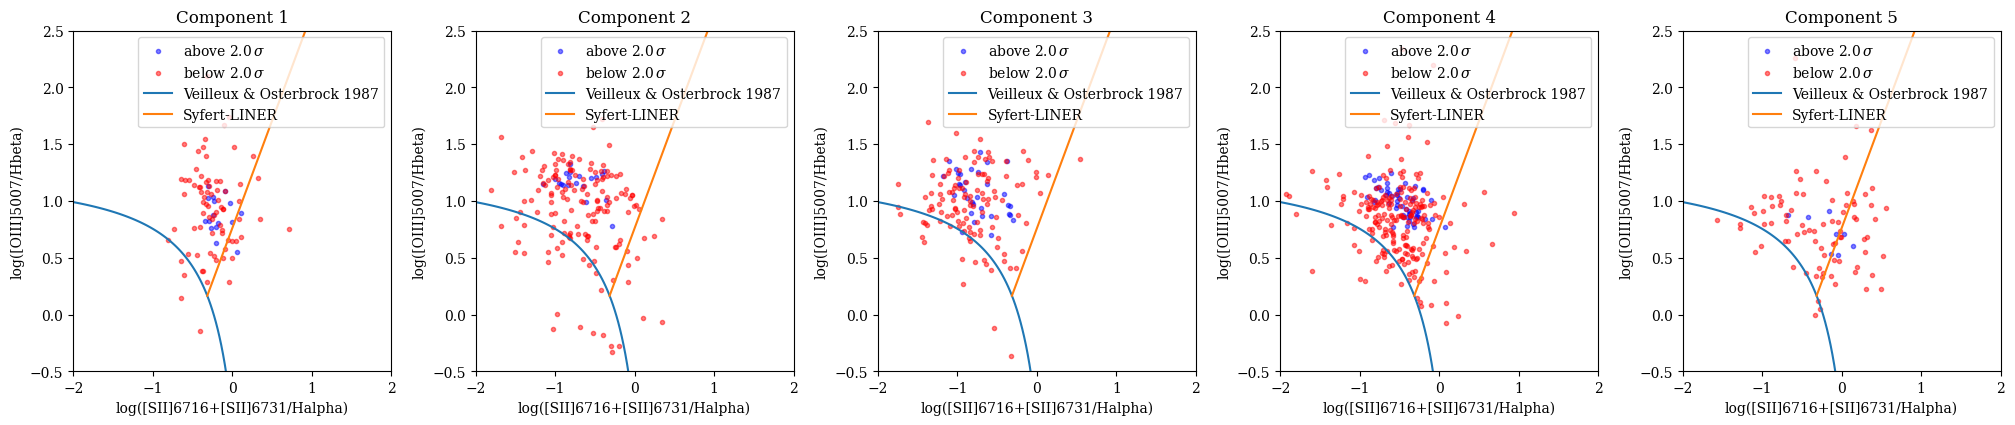

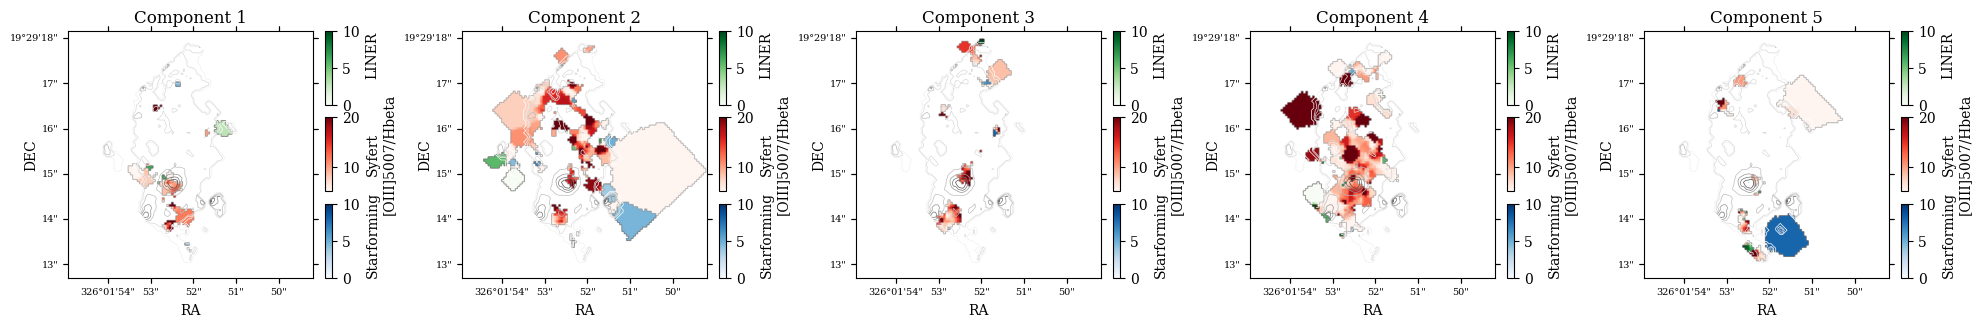

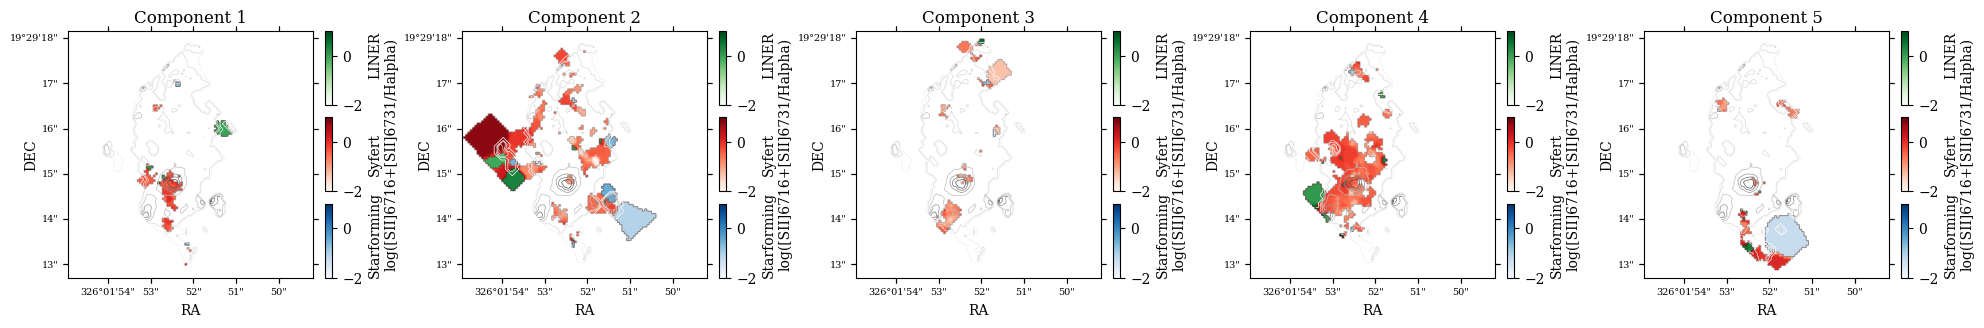

In [11]:
vo87 = AGNLine(0.72, -0.32, 1.3, "Veilleux & Osterbrock 1987")
class LinerSy2Line:
    def __init__(self, v1, v2, label):
        self.v1 = v1
        self.v2 = v2
        self.label = label
    def __call__(self, data):
        return self.v1 * data + self.v2
liner_line = LinerSy2Line(1.89, 0.76, "Syfert-LINER")

bpt_diagram(2.,
            "[OIII]5007", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "[SII]6716+[SII]6731", "SII/output_from_OIII_binned/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned/4C1971.line.npz",
            vo87, liner_line)

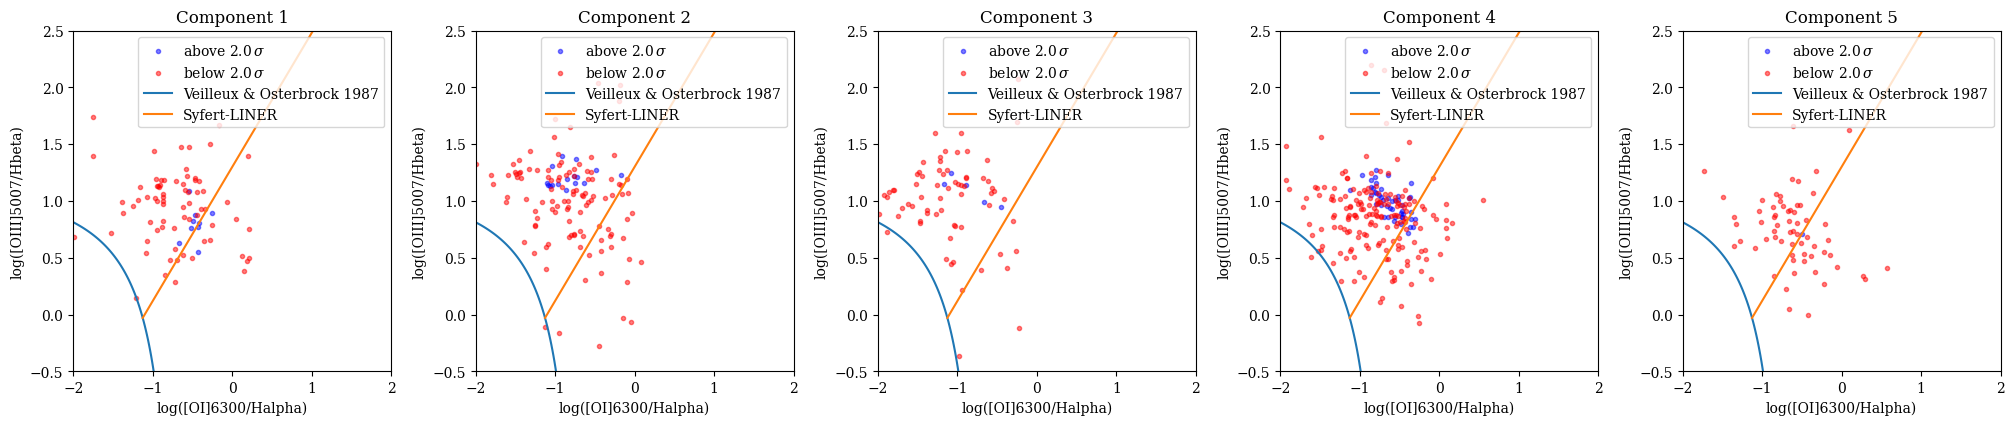

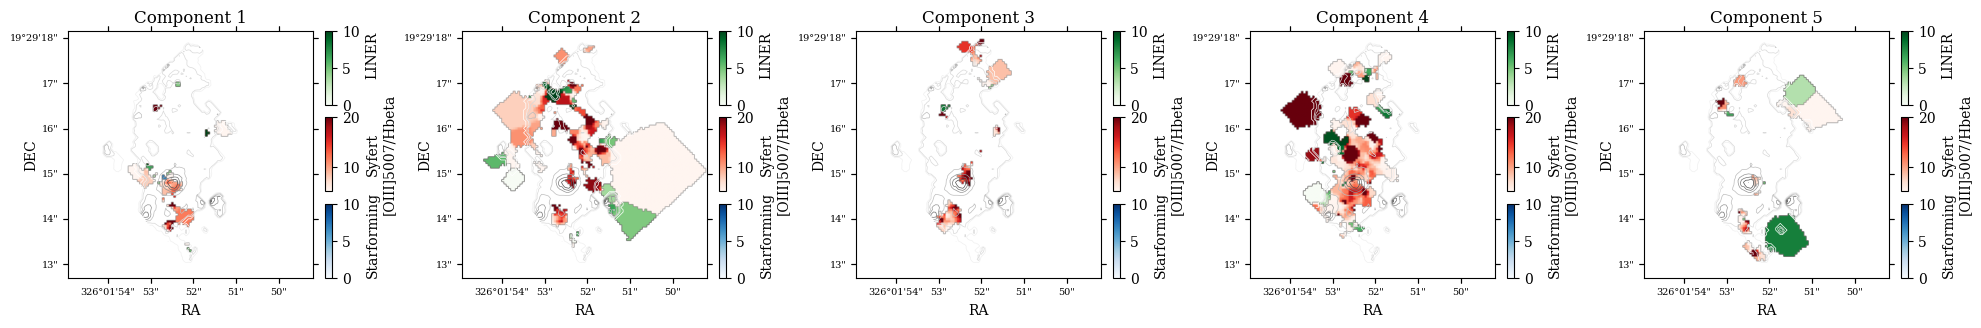

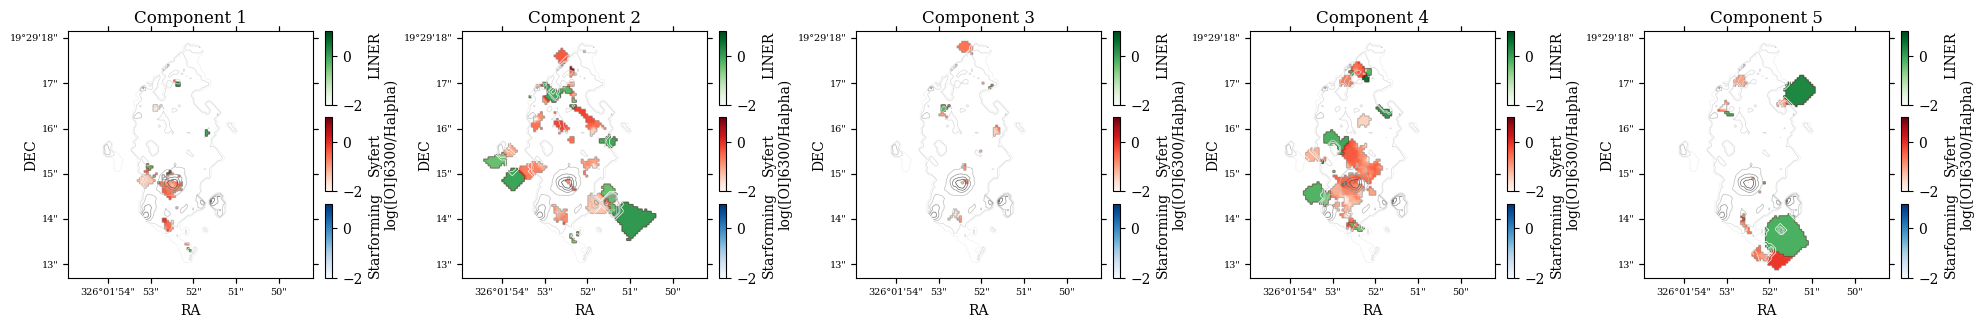

In [12]:
vo87OI = AGNLine(0.73, 0.59, 1.33, "Veilleux & Osterbrock 1987")
liner_lineOI = LinerSy2Line(1.18, 1.3, "Syfert-LINER")
bpt_diagram(2.,
            "[OIII]5007", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "[OI]6300", "OI/output_from_OIII_binned/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned/4C1971.line.npz",
            vo87OI, liner_lineOI)

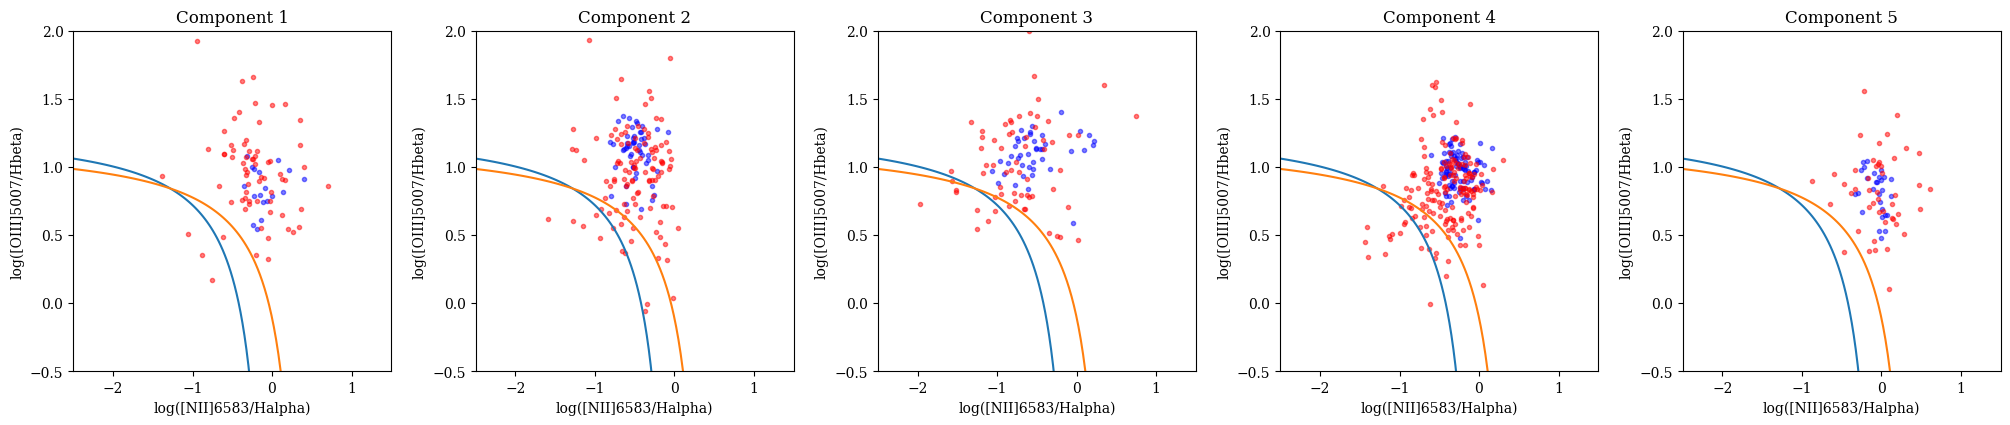

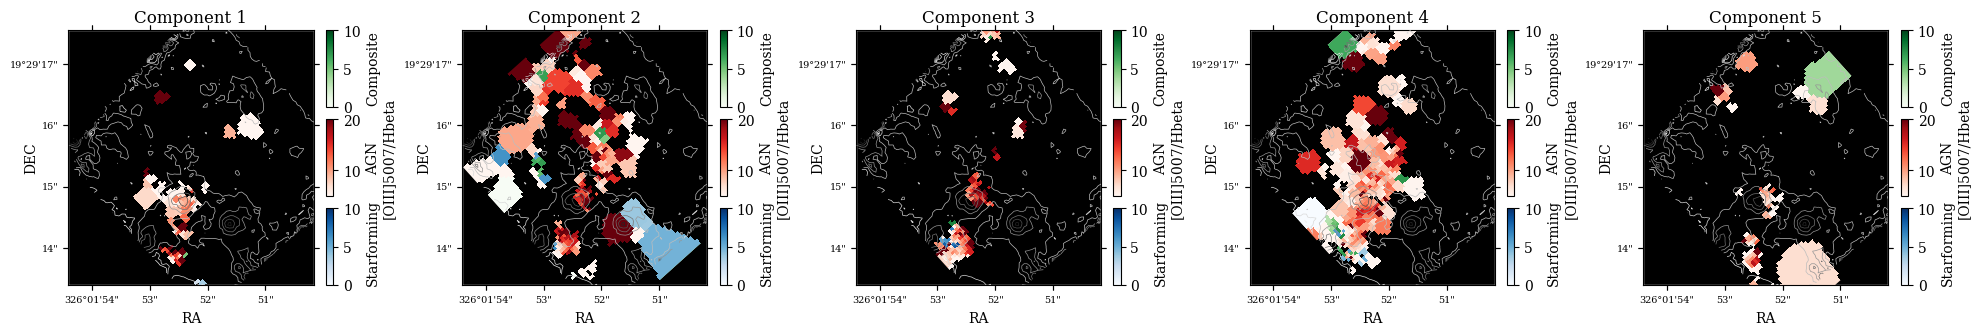

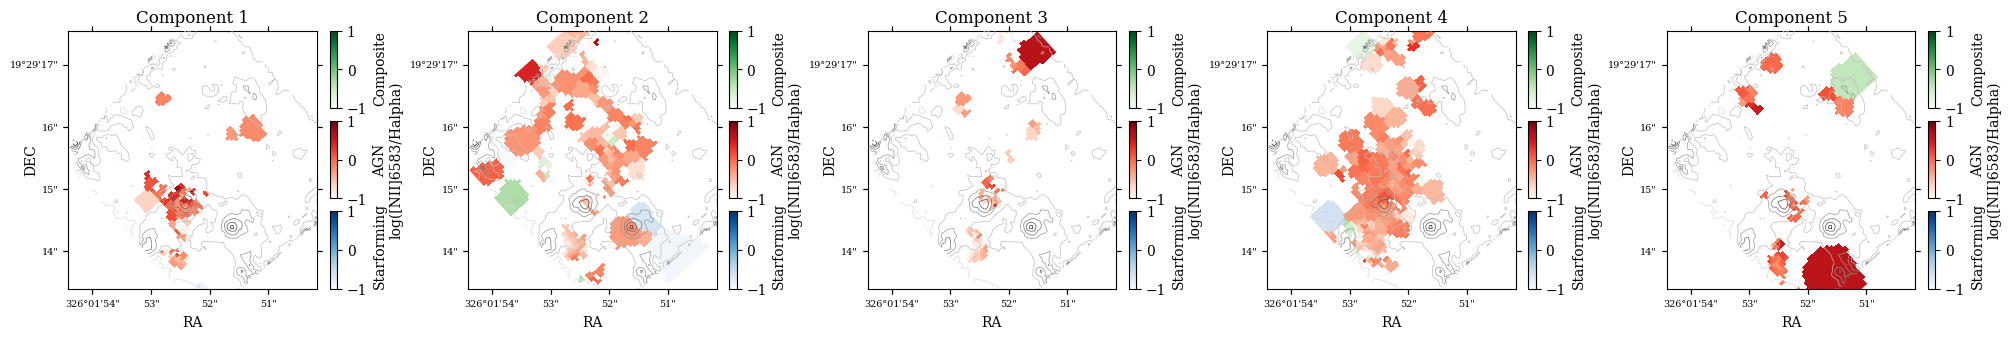

In [104]:
def bpt_diagram_no_resampling(
        snr_cut, reverse_bin,
        line1, file1,
        line2, file2,
        line3, file3,
        line4, file4,
        *lines
):
    "plot bpt diagram 1/2 (y-axis) vs 3/4 (x-axis)"
    np.seterr(all='ignore')

    contmap = np.load("contmap.npy")
    
    def get_data(file):
        file_data = np.load(file, allow_pickle=True)
        line_flux = file_data["emlflx"].item()
        line_fluxerr = file_data["emlflxerr"].item()
        line_sigma = file_data['emlsig'].item()
        line_ncomp = file_data['emlncomp'].item()
        return line_flux, line_fluxerr, line_sigma, line_ncomp
    
    # line1_flux, line1_fluxerr, line1_sigma, line1_ncomp = get_data(file1)
    # line2_flux, line2_fluxerr, line2_sigma, line2_ncomp = get_data(file2)
    # line3_flux, line3_fluxerr, line3_sigma, line3_ncomp = get_data(file3)
    # line4_flux, line4_fluxerr, line4_sigma, line4_ncomp = get_data(file4)

    line_list = [line1, line2, line3, line4]
    flux_list, fluxerr_list, sigma_list, ncomp_list = list(zip(get_data(file1), get_data(file2), get_data(file3), get_data(file4)))

    ########### extinction
    ext_line_list = ["Halpha", "Hbeta"]
    ext_flux_list, ext_fluxerr_list, ext_sigma_list, ext_ncomp_list = list(zip(get_data("Halpha/output_from_OIII_binned/4C1971.line.npz"), get_data("OIII/output_from_OIII_binned/4C1971.line.npz")))
    ###########

    cd_in = wcs.pixel_scale_matrix
    cd_out = wcs_out.pixel_scale_matrix

    R = cd_out @ np.linalg.inv(cd_in)

    angle = np.degrees(np.arctan2(R[0,1], R[1,1]))

    wcs_rot = wcs.deepcopy()

    theta = np.deg2rad(angle)

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    wcs_rot.wcs.pc = R @ wcs_rot.wcs.pc

    ncomp = np.max([int(np.nanmax(n[l])) for n, l in zip(ncomp_list, line_list)])
    fig, axs = plt.subplots(1, ncomp, figsize=(20,4))
    fig2, axs2 = plt.subplots(1, ncomp, figsize=(20,4), subplot_kw={"projection": wcs_rot})
    fig3, axs3 = plt.subplots(1, ncomp, figsize=(20,4), subplot_kw={"projection": wcs_rot})
    fig.tight_layout(w_pad=3, h_pad=0)
    # fig2.tight_layout(w_pad=5, h_pad=0)
    fig2.tight_layout(w_pad=2, h_pad=0)
    fig2.subplots_adjust(left=0.04, right=0.95, top=0.95, bottom=0.05)
    # fig2.tight_layout()
    # fig3.tight_layout(w_pad=5, h_pad=0)
    fig3.tight_layout(w_pad=2, h_pad=0)

    for i in range(ncomp):
        # ignore spaxels without linefit
        for line, flux, fluxerr, sigma in zip(line_list, flux_list, fluxerr_list, sigma_list):
            mask = (sigma[f"c{i+1}"][line] == 0.)
            flux[f"fc{i+1}"][line][mask] = np.nan
            fluxerr[f"fc{i+1}"][line][mask] = np.nan

        above_cut = np.ones_like(flux_list[0][f"fc{i+1}"][line_list[0]], dtype=bool)
        for line, flux, fluxerr in zip(line_list, flux_list, fluxerr_list):
            snr = flux[f"fc{i+1}"][line] / fluxerr[f"fc{i+1}"][line]
            # if snr_cut:
            #     flux[f"fc{i+1}"][line][snr < snr_cut] = np.nan
            above_cut *= (snr > snr_cut)
        flux0 = flux_list[0][f"fc{i+1}"][line_list[0]]
        flux1 = flux_list[1][f"fc{i+1}"][line_list[1]]
        flux2 = flux_list[2][f"fc{i+1}"][line_list[2]]
        flux3 = flux_list[3][f"fc{i+1}"][line_list[3]]

        ############################ dust
        flux_Halpha = ext_flux_list[0][f"fc{i+1}"][ext_line_list[0]]
        flux_Hbeta = ext_flux_list[1][f"fc{i+1}"][ext_line_list[1]]

        lambda_Halpha = list(linelist(["Halpha"])["lines"])[0]
        lambda_Hbeta = list(linelist(["Hbeta"])["lines"])[0]
        def extinction_curve(lamb):
            if 0.63 <= lamb < 2.2: #micron
                return 2.659 * (-1.857 + 1.040/lamb) + 4.05
            elif 0.12 <= lamb < 0.63:
                return 2.659 * (-2.156 + 1.509/lamb - 0.198/lamb**2 + 0.011/lamb**3) + 4.05
            else:
                raise ValueError
            
        color_excess = 2.5/(extinction_curve(lambda_Hbeta)-extinction_curve(lambda_Halpha)) * np.log10((flux_Halpha/flux_Hbeta)/2.86)
        color_excess = np.where(np.isinf(color_excess), np.nan, color_excess)

        wavelength_list = list(linelist(line_list)["lines"])

        flux0 = flux0 * 10**(0.4*extinction_curve(wavelength_list[0])*color_excess)
        flux1 = flux1 * 10**(0.4*extinction_curve(wavelength_list[1])*color_excess)
        flux2 = flux2 * 10**(0.4*extinction_curve(wavelength_list[2])*color_excess)
        flux3 = flux3 * 10**(0.4*extinction_curve(wavelength_list[3])*color_excess)

        #############################
        y_data = np.log10(np.where(flux0 > 0.0001, flux0, np.nan) / np.where(flux1 > 0.0001, flux1, np.nan))
        x_data = np.log10(np.where(flux2 > 0.0001, flux2, np.nan) / np.where(flux3 > 0.0001, flux3, np.nan))

        below_list = []
        for l in lines:
            below_l = y_data < l(x_data)
            if isinstance(l, AGNLine):
                below_l[x_data > -l.v2] = False
            below_list.append(below_l)
        if len(below_list) == 2:
            below_line = np.logical_or(*below_list)
        elif len(below_list) == 1:
            below_line = below_list[0]
        elif len(below_list) == 0:
            below_line = np.zeros_like(x_data, dtype=bool)
        else:
            raise NotImplementedError("2 lines max")


        # axs[i].scatter(x_data[below_line].flatten(), y_data[below_line].flatten(), c="black", marker="x", alpha=0.5, label="below line")
        axs[i].scatter(x_data[above_cut].flatten(), y_data[above_cut].flatten(), c="blue", marker=".", alpha=0.5, label=f"above {snr_cut}$\\,\\sigma$")
        axs[i].scatter(x_data[~above_cut].flatten(), y_data[~above_cut].flatten(), c="red", marker=".", alpha=0.5, label=f"below {snr_cut}$\\,\\sigma$")
        # axs[i].scatter(x_data.flatten(), y_data.flatten(), c=~above_cut.flatten(), cmap="bwr", marker=".", alpha=0.5)
        # x1 = np.linspace(-2, -0.08, 100)
        # x2 = np.linspace(-2, 0.34, 100)
        # axs[i].plot(x1, 0.61 / (x1 - 0.05) + 1.3, label="Kauffmann+03")  # Kauffmann+03
        # axs[i].plot(x2, 0.61 / (x2 - 0.47) + 1.19, label="Kewley+01")  # Kewley+01
        for l in lines:
            if isinstance(l, AGNLine):
                x = np.linspace(-2.5, -l.v2-0.1, 100)
                axs[i].plot(x, l(x), label=l.label)
            else:
                y1 = lines[0].v1
                y2 = lines[0].v2
                y3 = lines[0].v3
                x1 = lines[1].v1
                x2 = lines[1].v2
                A = (-(x1*y2+x2-y3)-np.sqrt((x1*y2+x2-y3)**2-4*x1*(y2*x2-y2*y3-y1)))/(2*x1)
                # print(A)
                x_ = np.linspace(A, 2, 100)
                axs[i].plot(x_, l(x_), label=l.label)
        axs[i].set_xlim(-2.5,1.5)
        axs[i].set_ylim(-0.5,2.0)
        axs[i].set_ylabel(f"log({line_list[0]}/{line_list[1]})")
        axs[i].set_xlabel(f"log({line_list[2]}/{line_list[3]})")
        # axs[i].legend()
        axs[i].set_title(f"Component {i+1}")

        ################
        below_line[~np.isfinite(x_data)] = False
        below_line[~np.isfinite(y_data)] = False

        ### axs2 ###
        data = y_data
        nx, ny = data.shape
        cx, cy = wcs.wcs.crpix

        # crpix = np.array(wcs_rot.wcs.crpix)
        # crpix_shifted = crpix - np.array([cx, cy])
        # crpix_rot = R @ crpix_shifted
        # wcs_rot.wcs.crpix = crpix_rot + np.array([cx, cy])

        # print(wcs_out.pixel_to_world(cx, cy))
        # print(wcs_rot.pixel_to_world(cx, cy))

        # rot = transforms.Affine2D().rotate_deg(-angle)
        rot = transforms.Affine2D().translate(-cx, -cy).rotate_deg(-angle).translate(cx, cy)

        im_agn = axs2[i].imshow(reverse_bin(10**data).T, origin="lower", vmax=20, vmin=5, cmap="Reds", interpolation="nearest", transform=rot+axs2[i].get_transform("pixel"))
        im_comp = axs2[i].imshow(reverse_bin(np.where(below_list[1], 10*data, np.nan)).T, origin="lower", vmax=10, vmin=0, cmap="Greens", interpolation="nearest", transform=rot+axs2[i].get_transform("pixel"))
        im_sf = axs2[i].imshow(reverse_bin(np.where(below_list[0], 10*data, np.nan)).T, origin="lower", vmax=10, vmin=0, cmap="Blues", interpolation="nearest", transform=rot+axs2[i].get_transform("pixel"))
        im_cont = axs2[i].contour(contmap, cmap="Greys", zorder=10, linewidths=0.5, transform=rot+axs2[i].get_transform("pixel"))
        cb_height = 0.3
        spacing = 0.05
        cax1 = inset_axes(axs2[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, 2*(cb_height + spacing), 1, 1), bbox_transform=axs2[i].transAxes, borderpad=0)
        cax2 = inset_axes(axs2[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, cb_height + spacing, 1, 1), bbox_transform=axs2[i].transAxes, borderpad=0)
        cax3 = inset_axes(axs2[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, 0.0, 1, 1), bbox_transform=axs2[i].transAxes, borderpad=0)
        
        cb1 = fig2.colorbar(im_comp, cax=cax1)
        cb2 = fig2.colorbar(im_agn, cax=cax2)
        cb3 = fig2.colorbar(im_sf, cax=cax3)
        if isinstance(lines[1], AGNLine):
            cb1.set_label("Composite", loc="top")
            cb2.set_label(f"AGN\n{line_list[0]}/{line_list[1]}", loc="center")
            cb3.set_label("Starforming", loc="bottom")
        else:
            cb1.set_label("LINER", loc="top")
            cb2.set_label(f"Syfert\n{line_list[0]}/{line_list[1]}", loc="center")
            cb3.set_label("Starforming", loc="bottom")
        
        axs2[i].set_title(f"Component {i+1}")
        axs2[i].set_xlim(-10, nx)
        axs2[i].set_ylim(0, ny)
        axs2[i].set_xlabel("RA")
        axs2[i].set_ylabel("DEC", labelpad=-1.5)
        axs2[i].coords[0].set_major_formatter('dd:mm:ss')
        axs2[i].coords[0].set_ticklabel(size=7)
        axs2[i].coords[1].set_ticklabel(size=7)
        axs2[i].set_facecolor("black")
        ### ax3 ###
        data = x_data
        im_agn = axs3[i].imshow(reverse_bin(data).T, origin="lower", vmax=1, vmin=-1, cmap="Reds", interpolation="nearest", transform=rot+axs3[i].get_transform("pixel"))
        im_comp = axs3[i].imshow(reverse_bin(np.where(below_list[1], data, np.nan)).T, origin="lower", vmax=1, vmin=-1, cmap="Greens", interpolation="nearest", transform=rot+axs3[i].get_transform("pixel"))
        im_sf = axs3[i].imshow(reverse_bin(np.where(below_list[0], data, np.nan)).T, origin="lower", vmax=1, vmin=-1, cmap="Blues", interpolation="nearest", transform=rot+axs3[i].get_transform("pixel"))
        im_cont = axs3[i].contour(contmap, cmap="Greys", zorder=10, linewidths=0.5, transform=rot+axs3[i].get_transform("pixel"))
        cb_height = 0.3
        spacing = 0.05
        cax1 = inset_axes(axs3[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, 2*(cb_height + spacing), 1, 1), bbox_transform=axs3[i].transAxes, borderpad=0)
        cax2 = inset_axes(axs3[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, cb_height + spacing, 1, 1), bbox_transform=axs3[i].transAxes, borderpad=0)
        cax3 = inset_axes(axs3[i], width="3%", height=f"{cb_height*100}%", loc='lower left',
                        bbox_to_anchor=(1.05, 0.0, 1, 1), bbox_transform=axs3[i].transAxes, borderpad=0)
        
        cb1 = fig3.colorbar(im_comp, cax=cax1)
        cb2 = fig3.colorbar(im_agn, cax=cax2)
        cb3 = fig3.colorbar(im_sf, cax=cax3)
        if isinstance(lines[1], AGNLine):
            cb1.set_label("Composite", loc="top")
            cb2.set_label(f"AGN\nlog({line_list[2]}/{line_list[3]})", loc="center")
            cb3.set_label("Starforming", loc="bottom")
        else:
            cb1.set_label("LINER", loc="top")
            cb2.set_label(f"Syfert\nlog({line_list[2]}/{line_list[3]})", loc="center")
            cb3.set_label("Starforming", loc="bottom")

        axs3[i].set_title(f"Component {i+1}")
        axs3[i].set_xlim(-10, nx)
        axs3[i].set_ylim(0, ny)
        axs3[i].set_xlabel("RA")
        axs3[i].set_ylabel("DEC", labelpad=-1.5)
        axs3[i].coords[0].set_major_formatter('dd:mm:ss')
        axs3[i].coords[0].set_ticklabel(size=7)
        axs3[i].coords[1].set_ticklabel(size=7)
    fig.savefig(os.path.join("plots", f"component_BPT_diagram_{line_list[0]}-{line_list[1]}_{line_list[2]}-{line_list[3]}_ext_corr.pdf"), bbox_inches = "tight")
    fig2.savefig(os.path.join("plots", f"component_BPT_map_{line_list[0]}-{line_list[1]}_{lines[0].label}-{lines[1].label}_ext_corr.pdf"))#, bbox_inches = "tight")

class AGNLine:
    def __init__(self, v1, v2, v3, label):
        self.v1 = v1
        self.v2 = v2
        self.v3 = v3
        self.label = label
    def __call__(self, data):
        return self.v1 / (data + self.v2) + self.v3
kauffmann_line = AGNLine(0.61, -0.05, 1.3, "Kauffmann+03")
kewley_line = AGNLine(0.61, -0.47, 1.19, "Kewley+01")

bpt_diagram_no_resampling(2., reverse_bin,
            "[OIII]5007", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "[NII]6583", "Halpha/output_from_OIII_binned/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned/4C1971.line.npz",
            kauffmann_line, kewley_line)

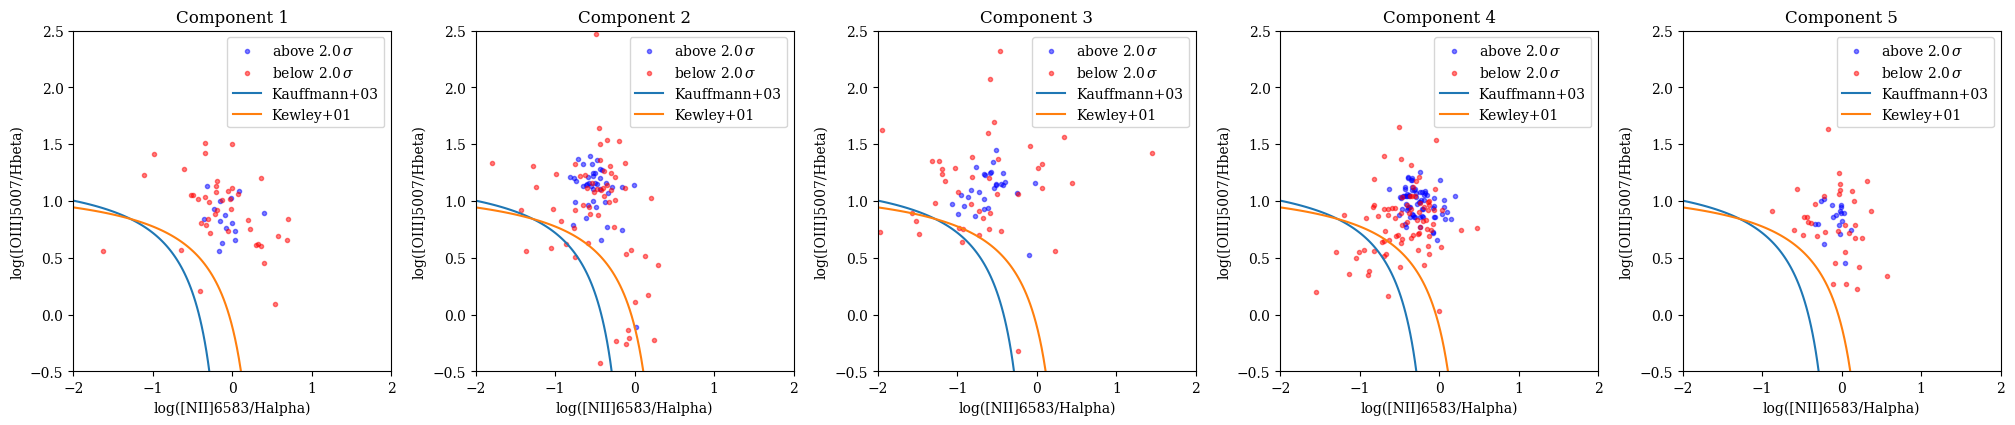

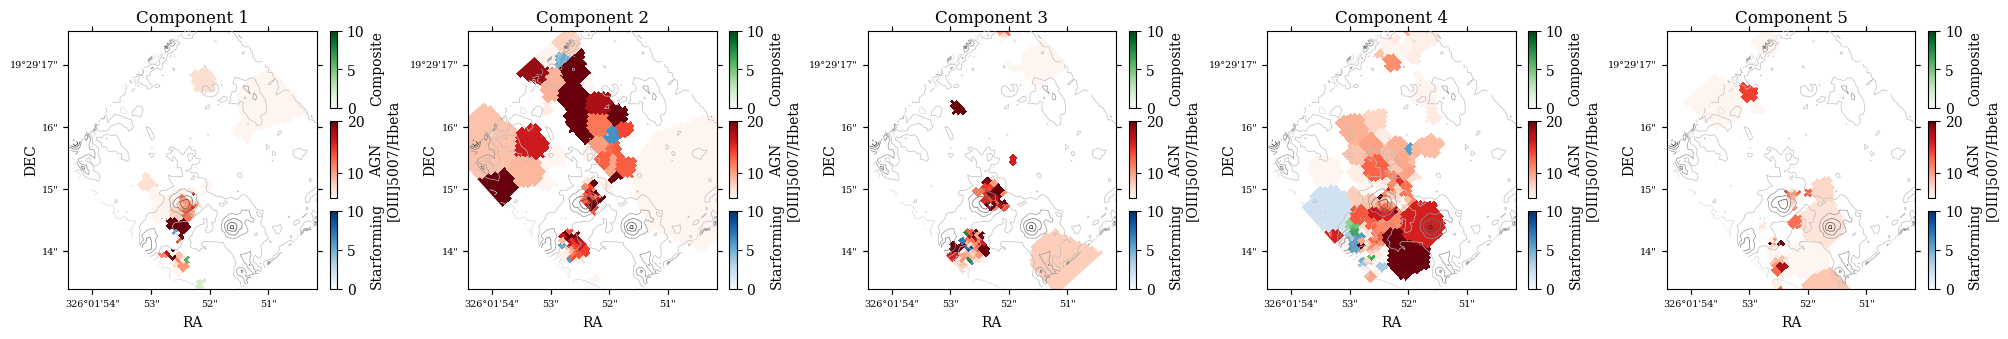

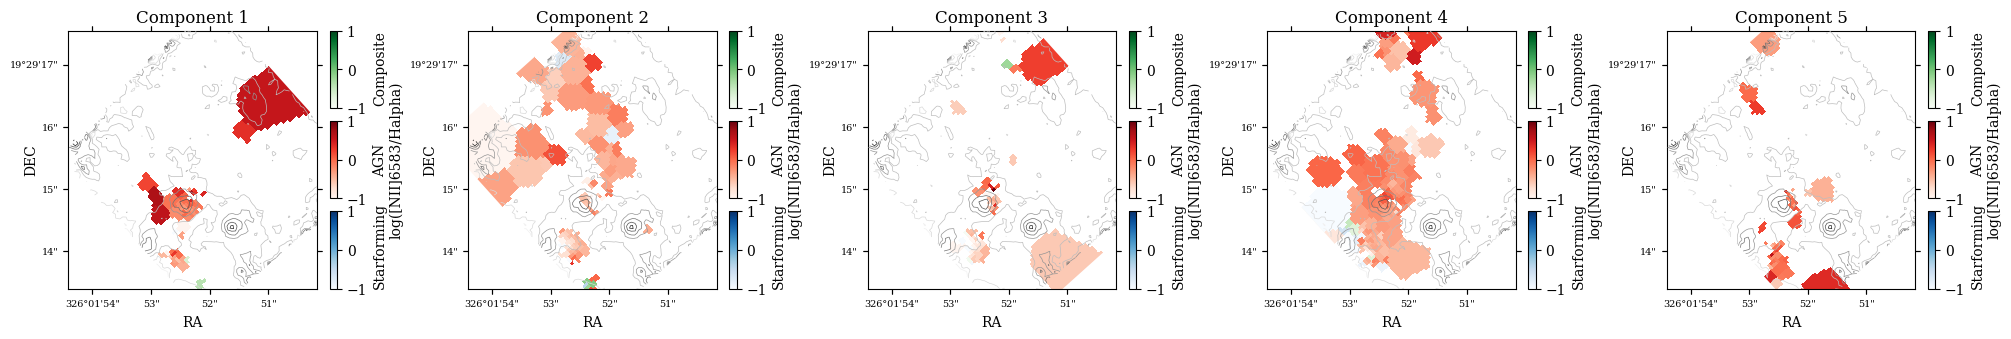

In [17]:
bpt_diagram_no_resampling(2., reverse_bin_2,
            "[OIII]5007", "OIII/output_from_OIII_binned_2/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned_2/4C1971.line.npz",
            "[NII]6583", "Halpha/output_from_OIII_binned_2/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned_2/4C1971.line.npz",
            kauffmann_line, kewley_line)

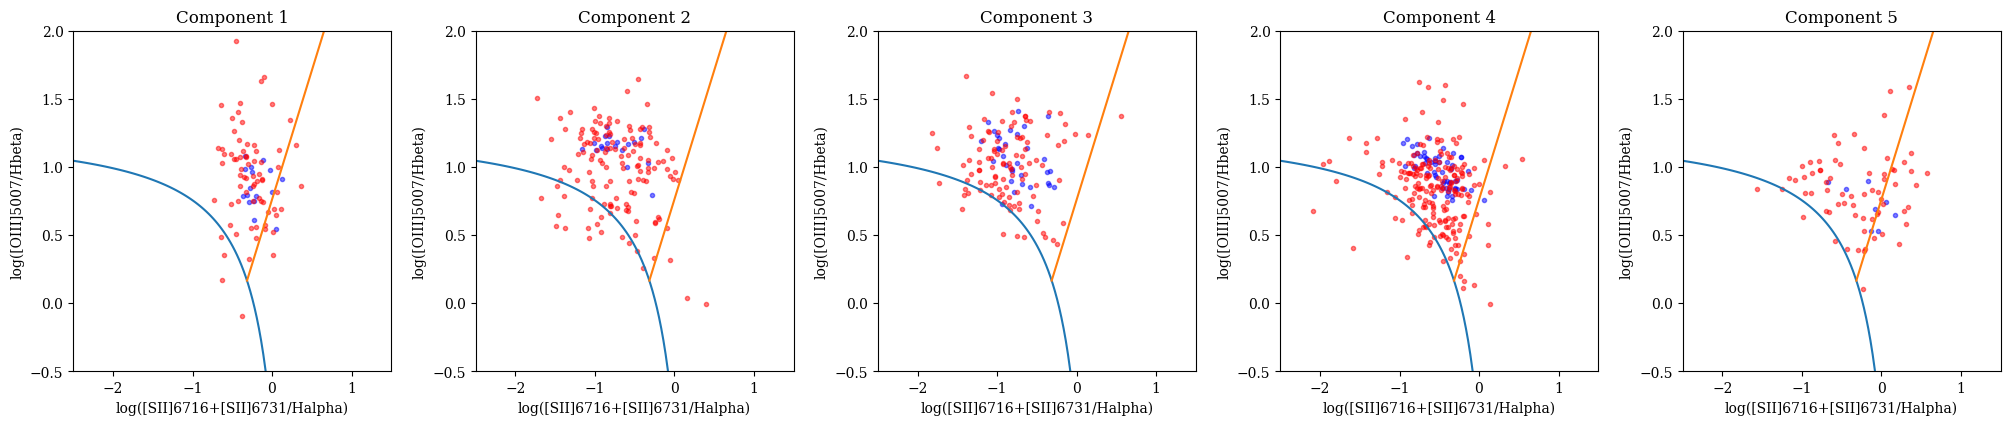

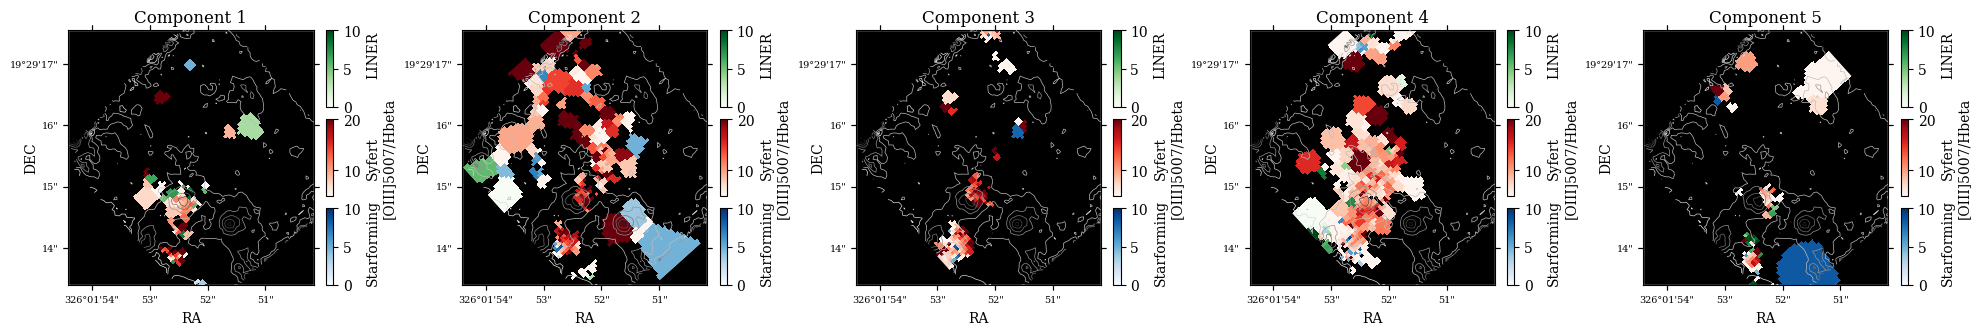

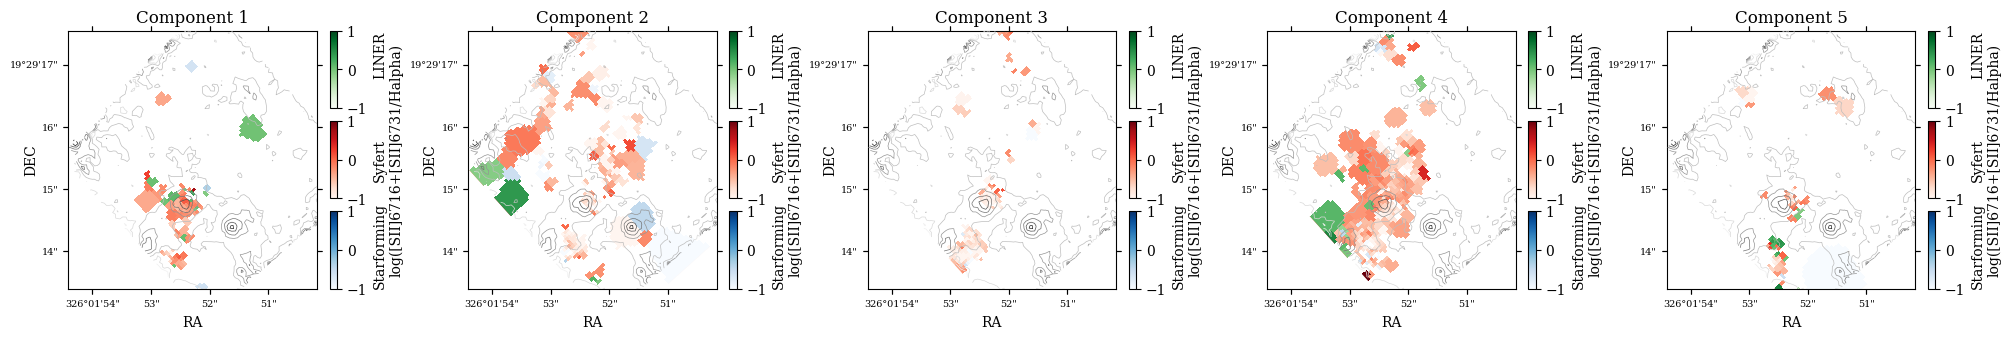

In [105]:
vo87 = AGNLine(0.72, -0.32, 1.3, "Veilleux & Osterbrock 1987")
class LinerSy2Line:
    def __init__(self, v1, v2, label):
        self.v1 = v1
        self.v2 = v2
        self.label = label
    def __call__(self, data):
        return self.v1 * data + self.v2
liner_line = LinerSy2Line(1.89, 0.76, "Syfert-LINER")

bpt_diagram_no_resampling(2., reverse_bin,
            "[OIII]5007", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "[SII]6716+[SII]6731", "SII/output_from_OIII_binned/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned/4C1971.line.npz",
            vo87, liner_line)

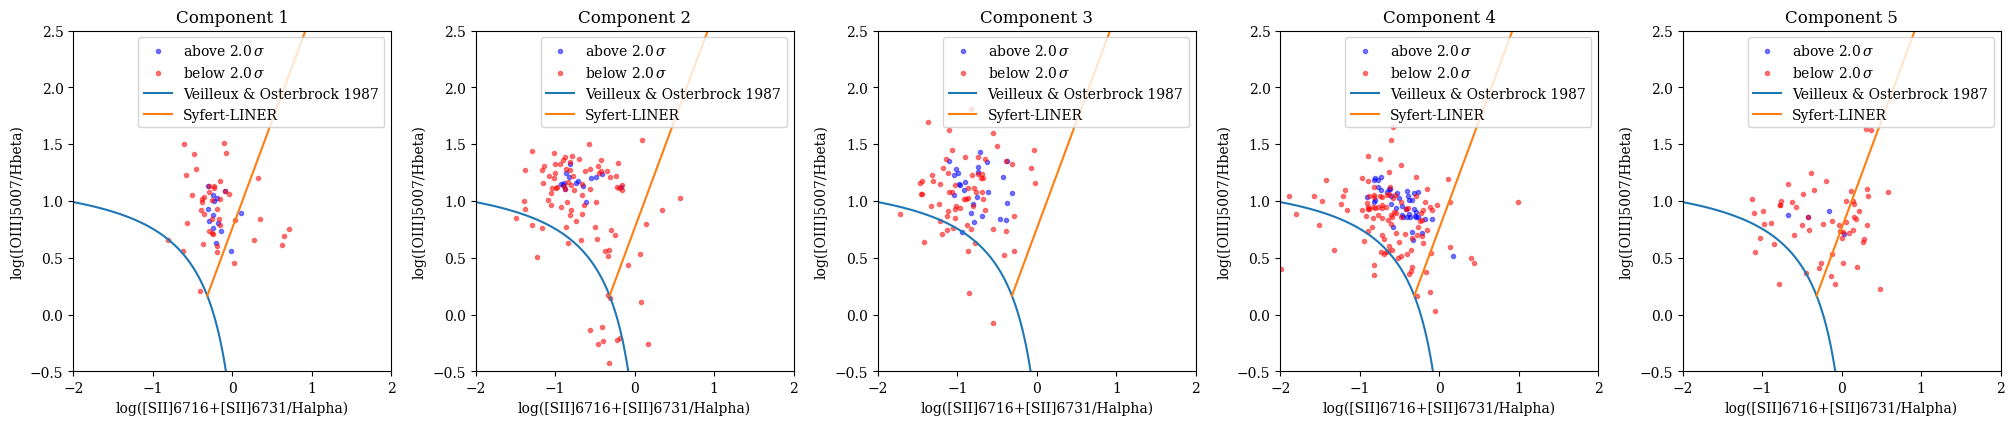

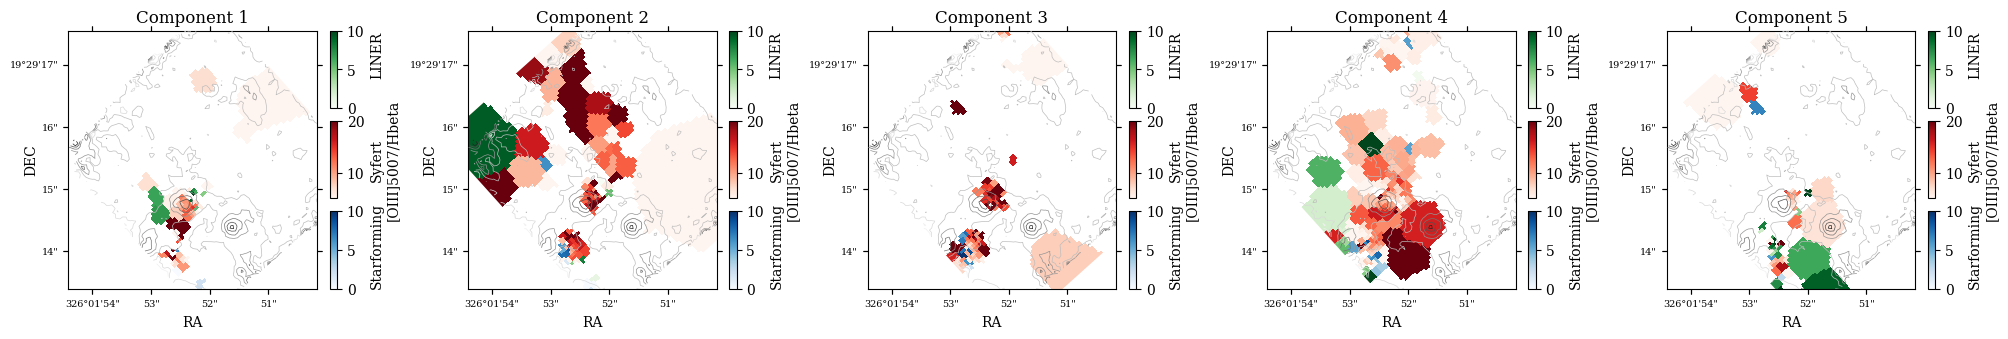

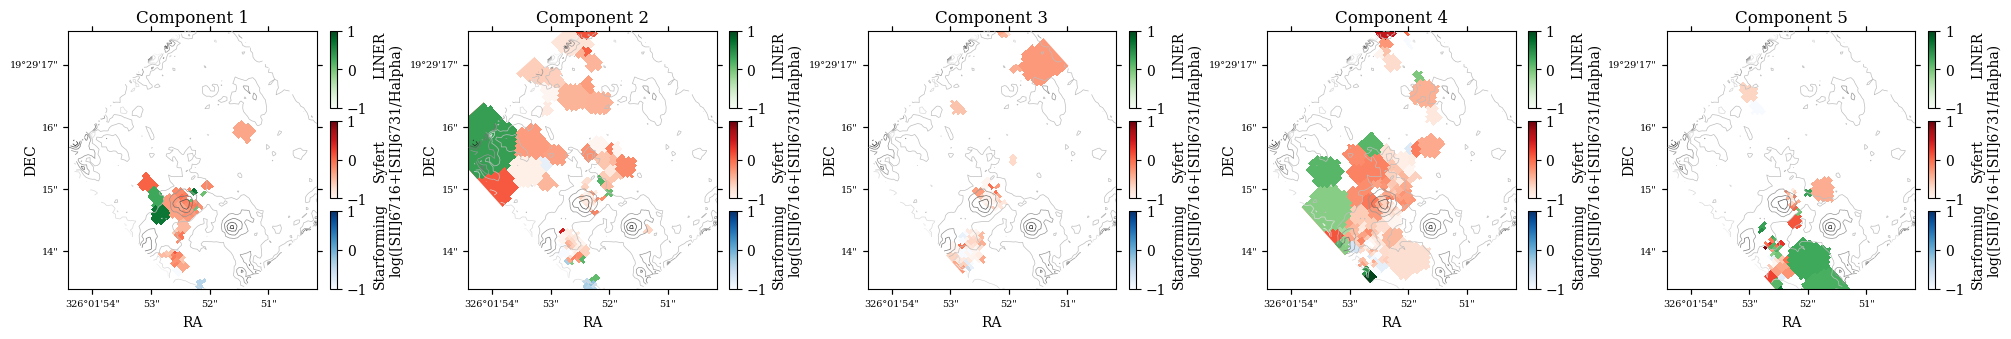

In [19]:
bpt_diagram_no_resampling(2., reverse_bin_2,
            "[OIII]5007", "OIII/output_from_OIII_binned_2/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned_2/4C1971.line.npz",
            "[SII]6716+[SII]6731", "SII/output_from_OIII_binned_2/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned_2/4C1971.line.npz",
            vo87, liner_line)

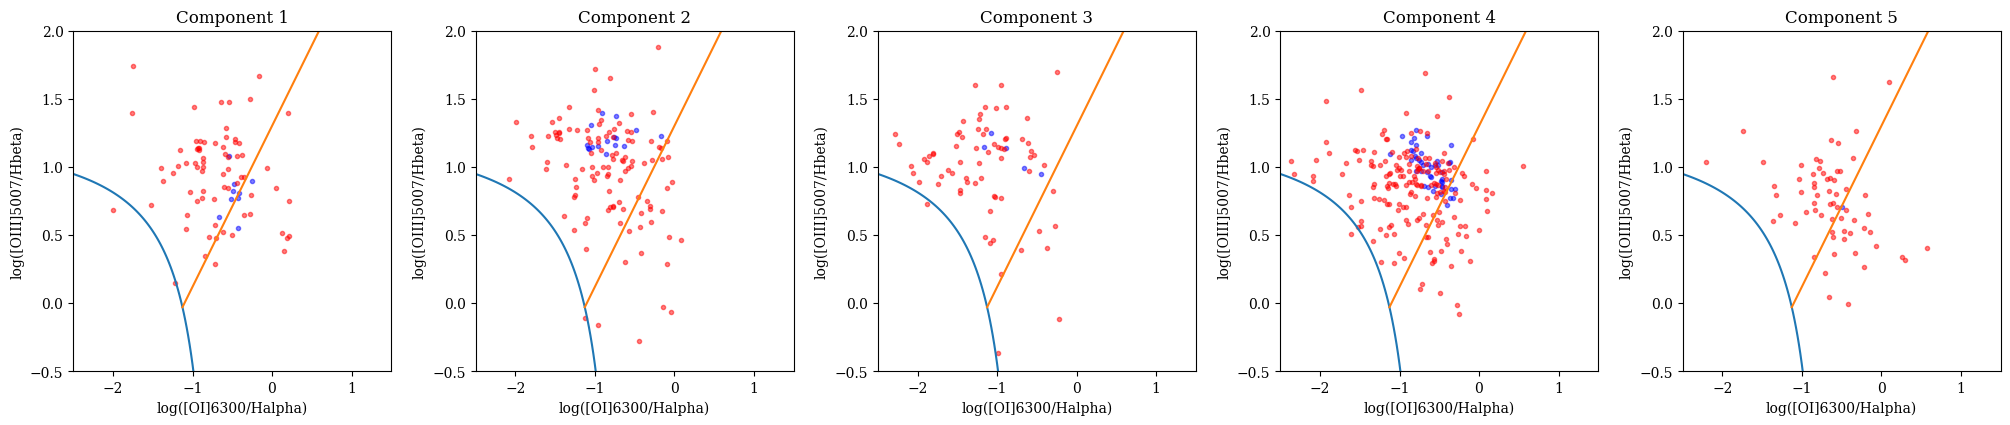

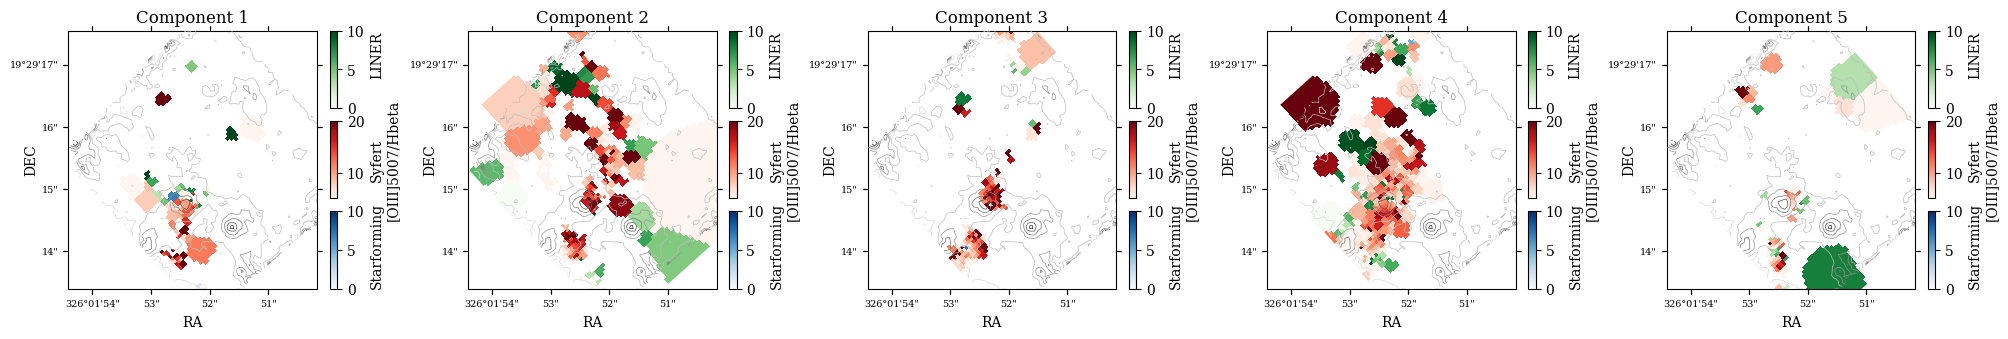

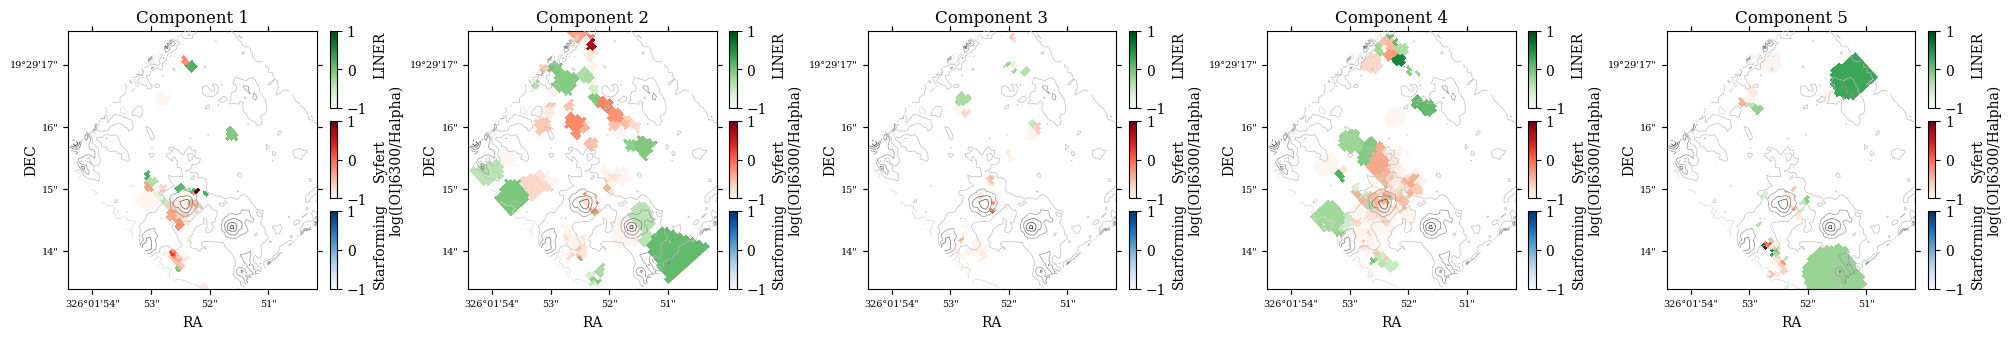

In [25]:
vo87OI = AGNLine(0.73, 0.59, 1.33, "Veilleux & Osterbrock 1987")
liner_lineOI = LinerSy2Line(1.18, 1.3, "Syfert-LINER")
bpt_diagram_no_resampling(2., reverse_bin,
            "[OIII]5007", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned/4C1971.line.npz",
            "[OI]6300", "OI/output_from_OIII_binned/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned/4C1971.line.npz",
            vo87OI, liner_lineOI)

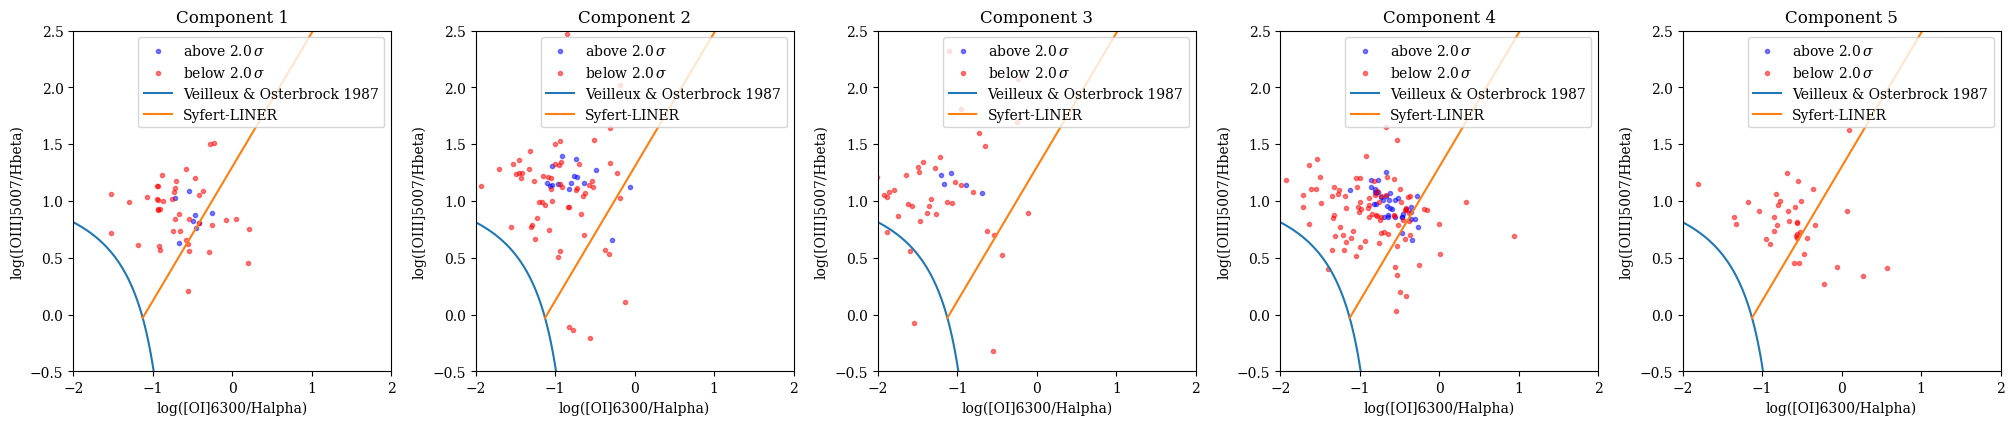

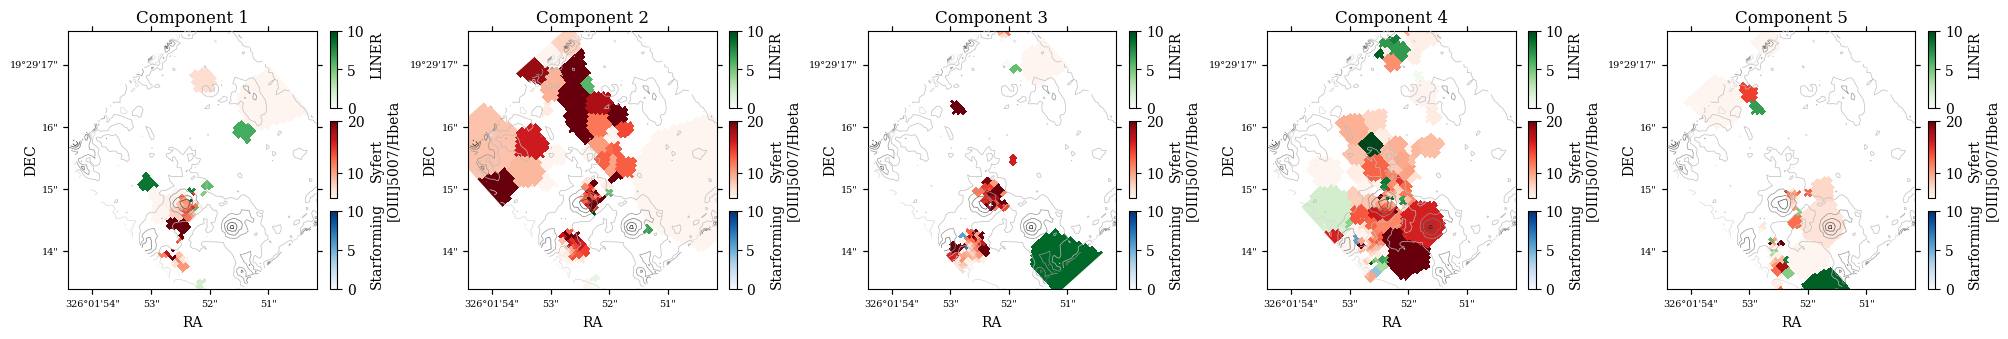

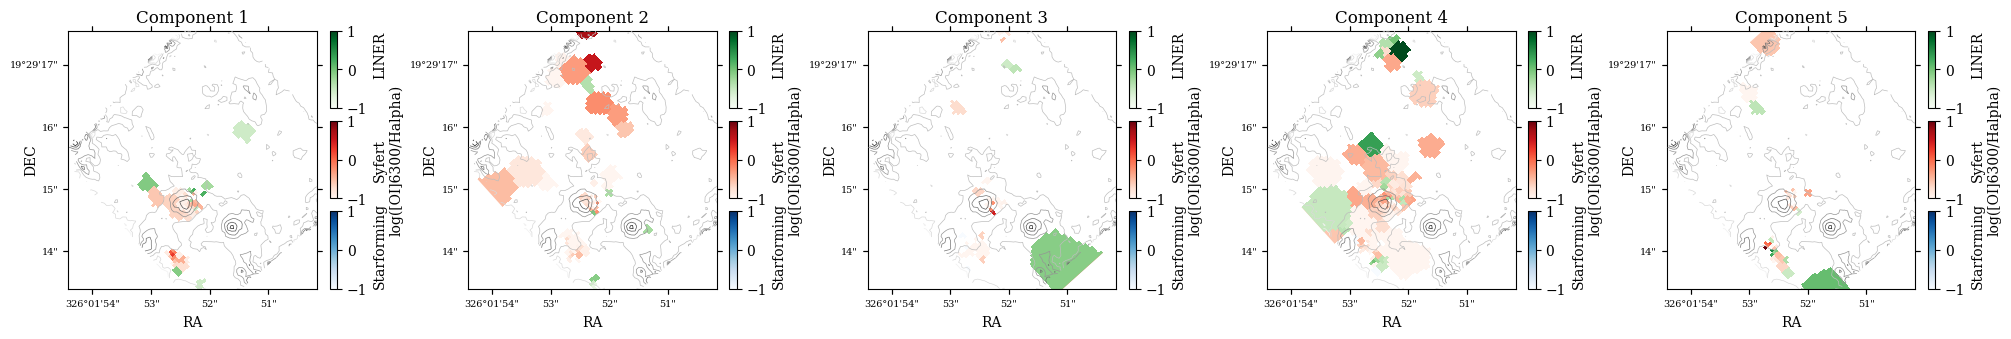

In [21]:
bpt_diagram_no_resampling(2., reverse_bin_2,
            "[OIII]5007", "OIII/output_from_OIII_binned_2/4C1971.line.npz",
            "Hbeta", "OIII/output_from_OIII_binned_2/4C1971.line.npz",
            "[OI]6300", "OI/output_from_OIII_binned_2/4C1971.line.npz",
            "Halpha", "Halpha/output_from_OIII_binned_2/4C1971.line.npz",
            vo87OI, liner_lineOI)

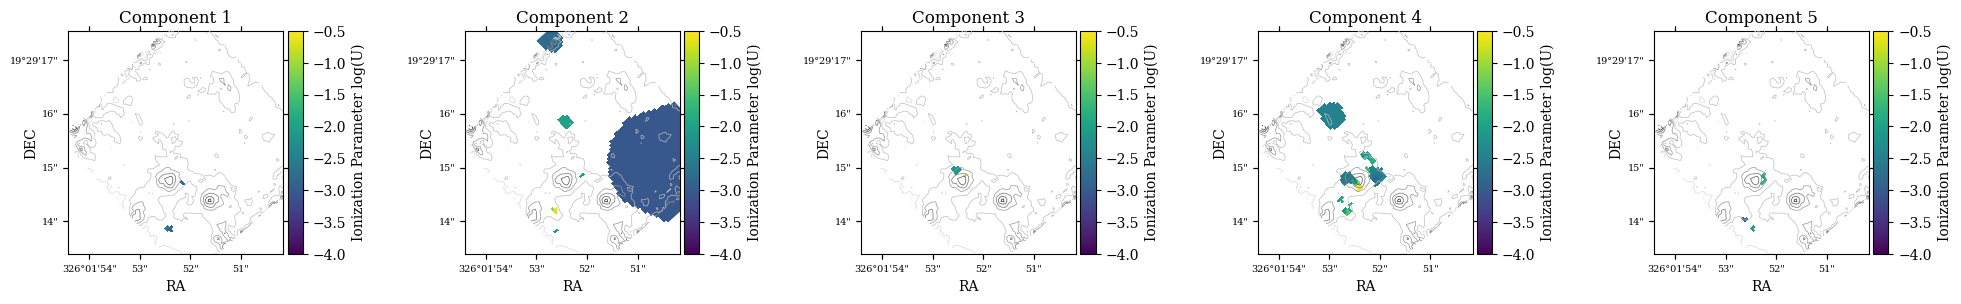

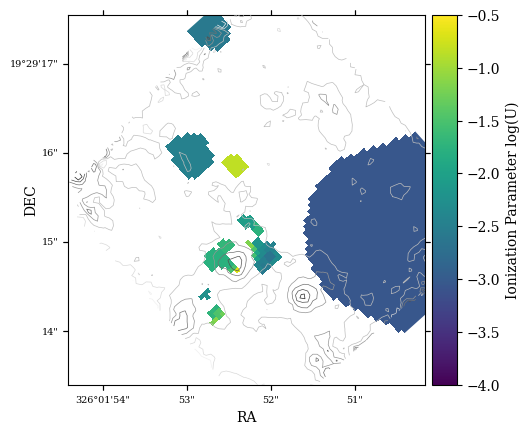

In [50]:
def ionization_parameter(file_OIII, file_OII):
    file_data_OII = np.load(file_OII, allow_pickle=True)
    file_data_OIII = np.load(file_OIII, allow_pickle=True)
    line_flux_OII = file_data_OII["emlflx"].item()
    line_flux_OIII = file_data_OIII["emlflx"].item()
    line_fluxerr_OII = file_data_OII["emlflxerr"].item()
    line_fluxerr_OIII = file_data_OIII["emlflxerr"].item()
    # line_sigma = file_data['emlsig'].item()
    # line_ncomp = file_data['emlncomp'].item()
    ncomp=5
    fig, axs = plt.subplots(1, ncomp, figsize=(20,4), subplot_kw={"projection": wcs_rot})
    # fig2, axs2 = plt.subplots(1, ncomp, figsize=(20,4))
    fig.tight_layout(w_pad=3, h_pad=0)
    fig.subplots_adjust(left=0.04, right=0.95, top=0.95, bottom=0.05)
    # fig2.tight_layout(w_pad=3, h_pad=0)
    contmap = np.load("contmap.npy")

    for i in range(ncomp):
        flux_OII = line_flux_OII[f"fc{i+1}"]["[OII]3726"]
        fluxerr_OII = line_fluxerr_OII[f"fc{i+1}"]["[OII]3726"]
        flux_OIII = line_flux_OIII[f"fc{i+1}"]["[OIII]5007"]
        flux_OII = np.where(flux_OII/fluxerr_OII > 2, flux_OII, np.nan)
        x = np.log10(flux_OIII / flux_OII)

        U = 0.57*x**2 + 1.38*x - 3.14
        im0 = axs[i].imshow(reverse_bin_2(U).T, origin="lower", vmin=-4, vmax=-0.5, interpolation="nearest", transform=rot+axs[i].get_transform("pixel"))
        cax0 = make_axes_locatable(axs[i]).append_axes("right", size="7%", pad="2%", axes_class = Axes)
        cb0 = fig.colorbar(im0, cax=cax0, label=f"Ionization Parameter log(U)")
        nx, ny = U.shape
        axs[i].set_title(f"Component {i+1}")
        axs[i].set_xlim(-10, nx)
        axs[i].set_ylim(0, ny)
        axs[i].set_xlabel("RA")
        axs[i].set_ylabel("DEC", labelpad=-1.5)
        axs[i].coords[0].set_major_formatter('dd:mm:ss')
        axs[i].coords[0].set_ticklabel(size=7)
        axs[i].coords[1].set_ticklabel(size=7)

        axs[i].contour(contmap, cmap="Greys", zorder=10, linewidths=0.5, transform=rot+axs[i].get_transform("pixel"))
        # axs2[i].contour(contmap, cmap="Greys", zorder=10, linewidths=0.5)

        # im1 = axs2[i].imshow(reverse_bin_2(flux_OII).T, origin="lower")
        # cax1 = make_axes_locatable(axs2[i]).append_axes("right", size="7%", pad="2%", axes_class = Axes)
        # cb0 = fig2.colorbar(im1, cax=cax1, label=f"OII flux")

    flux_OII = line_flux_OII["ftot"]["[OII]3726"]
    fluxerr_OII = line_fluxerr_OII["ftot"]["[OII]3726"]
    flux_OII = np.where(flux_OII/fluxerr_OII > 2, flux_OII, np.nan)
    xtot = np.log10(line_flux_OIII["ftot"]["[OIII]5007"]/flux_OII)
    Utot = 0.57*xtot**2 + 1.38*xtot - 3.14
        
    fig3, axs3 = plt.subplots(1,1, subplot_kw={"projection": wcs_rot})
    axs3.contour(contmap, cmap="Greys", zorder=10, linewidths=0.5, transform=rot+axs3.get_transform("pixel"))
    im3 = axs3.imshow(reverse_bin_2(Utot).T, origin="lower", vmin=-4, vmax=-0.5, interpolation="nearest", transform=rot+axs3.get_transform("pixel"))
    cax3 = make_axes_locatable(axs3).append_axes("right", size="7%", pad="2%", axes_class = Axes)
    cb0 = fig3.colorbar(im3, cax=cax3, label=f"Ionization Parameter log(U)")
    nx, ny = Utot.shape
    # axs3.set_title(f"")
    axs3.set_xlim(-10, nx)
    axs3.set_ylim(0, ny)
    axs3.set_xlabel("RA")
    axs3.set_ylabel("DEC", labelpad=-1.5)
    axs3.coords[0].set_major_formatter('dd:mm:ss')
    axs3.coords[0].set_ticklabel(size=7)
    axs3.coords[1].set_ticklabel(size=7)
    fig.savefig(os.path.join("plots", "ionization_parameter_comp.pdf"))
    fig3.savefig(os.path.join("plots", "ionization_parameter_total.pdf"))

# 2020MNRAS.492.5675C 
ionization_parameter("OIII/output_from_OIII_binned_2/4C1971.line.npz",
                     "OII/output_from_OIII_binned_2/4C1971.line.npz")

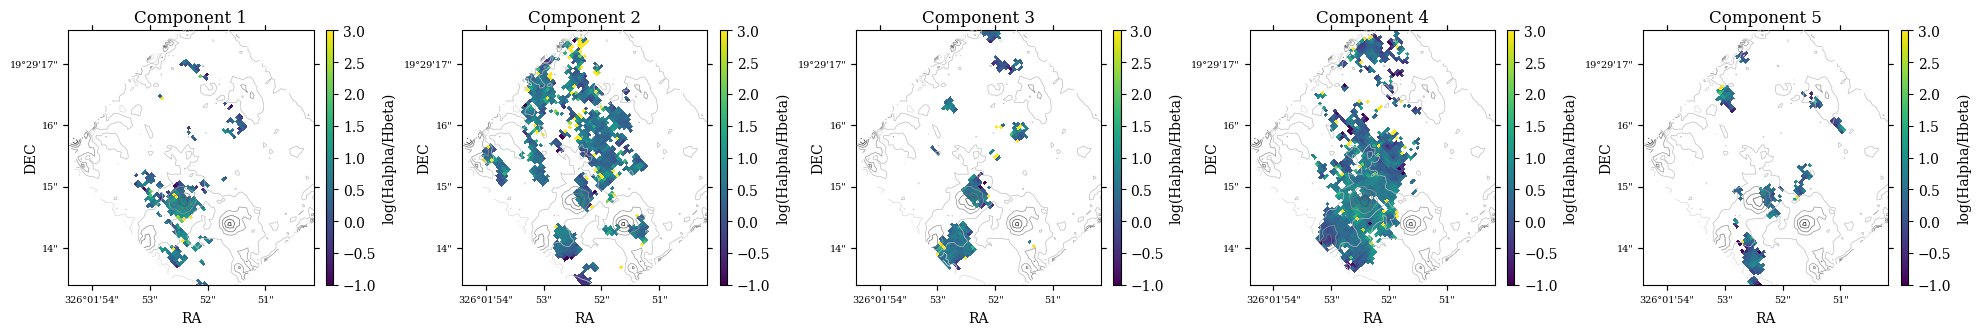

In [83]:
def line_ratio_map_no_resampling(
        reverse_bin,
        line1, file1,
        line2, file2
):

    np.seterr(all='ignore')

    contmap = np.load("contmap.npy")
    
    def get_data(file):
        file_data = np.load(file, allow_pickle=True)
        line_flux = file_data["emlflx"].item()
        line_fluxerr = file_data["emlflxerr"].item()
        line_sigma = file_data['emlsig'].item()
        line_ncomp = file_data['emlncomp'].item()
        return line_flux, line_fluxerr, line_sigma, line_ncomp
    
    # line1_flux, line1_fluxerr, line1_sigma, line1_ncomp = get_data(file1)
    # line2_flux, line2_fluxerr, line2_sigma, line2_ncomp = get_data(file2)
    # line3_flux, line3_fluxerr, line3_sigma, line3_ncomp = get_data(file3)
    # line4_flux, line4_fluxerr, line4_sigma, line4_ncomp = get_data(file4)

    line_list = [line1, line2]
    flux_list, fluxerr_list, sigma_list, ncomp_list = list(zip(get_data(file1), get_data(file2)))

    cd_in = wcs.pixel_scale_matrix
    cd_out = wcs_out.pixel_scale_matrix

    R = cd_out @ np.linalg.inv(cd_in)

    angle = np.degrees(np.arctan2(R[0,1], R[1,1]))

    wcs_rot = wcs.deepcopy()

    theta = np.deg2rad(angle)

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    wcs_rot.wcs.pc = R @ wcs_rot.wcs.pc

    ncomp = np.max([int(np.nanmax(n[l])) for n, l in zip(ncomp_list, line_list)])
    fig2, axs2 = plt.subplots(1, ncomp, figsize=(20,4), subplot_kw={"projection": wcs_rot})
    # fig2.tight_layout(w_pad=5, h_pad=0)
    fig2.tight_layout(w_pad=2, h_pad=0)
    fig2.subplots_adjust(left=0.04, right=0.95, top=0.95, bottom=0.05)
    # fig2.tight_layout()

    for i in range(ncomp):
        # ignore spaxels without linefit
        for line, flux, fluxerr, sigma in zip(line_list, flux_list, fluxerr_list, sigma_list):
            mask = (sigma[f"c{i+1}"][line] == 0.)
            flux[f"fc{i+1}"][line][mask] = np.nan
            fluxerr[f"fc{i+1}"][line][mask] = np.nan

        flux0 = flux_list[0][f"fc{i+1}"][line_list[0]]
        flux1 = flux_list[1][f"fc{i+1}"][line_list[1]]

        ### axs2 ###
        data = np.log10(flux0/flux1)

        nx, ny = data.shape
        cx, cy = wcs.wcs.crpix
        rot = transforms.Affine2D().translate(-cx, -cy).rotate_deg(-angle).translate(cx, cy)

        im_agn = axs2[i].imshow(reverse_bin(data).T, origin="lower", vmin=-1, vmax=3, interpolation="nearest", transform=rot+axs2[i].get_transform("pixel"))
        
        im_cont = axs2[i].contour(contmap, cmap="Greys", zorder=10, linewidths=0.5, transform=rot+axs2[i].get_transform("pixel"))
        
        cax2 = inset_axes(axs2[i], width="3%", height=f"100%", loc='lower left',
                        bbox_to_anchor=(1.05, 0.0, 1, 1), bbox_transform=axs2[i].transAxes, borderpad=0)
        
        cb2 = fig2.colorbar(im_agn, cax=cax2)
        
        cb2.set_label(f"log({line_list[0]}/{line_list[1]})", loc="center")
        
        axs2[i].set_title(f"Component {i+1}")
        axs2[i].set_xlim(-10, nx)
        axs2[i].set_ylim(0, ny)
        axs2[i].set_xlabel("RA")
        axs2[i].set_ylabel("DEC", labelpad=-1.5)
        axs2[i].coords[0].set_major_formatter('dd:mm:ss')
        axs2[i].coords[0].set_ticklabel(size=7)
        axs2[i].coords[1].set_ticklabel(size=7)
        # axs2[i].set_facecolor("black")

line_ratio_map_no_resampling(
    lambda x: x,
    "Halpha", "output_Halpha/4C1971_other_lines_Halpha.line.npz",
    "Hbeta", "4C1971_neighbour_method.line.red.npz",
)

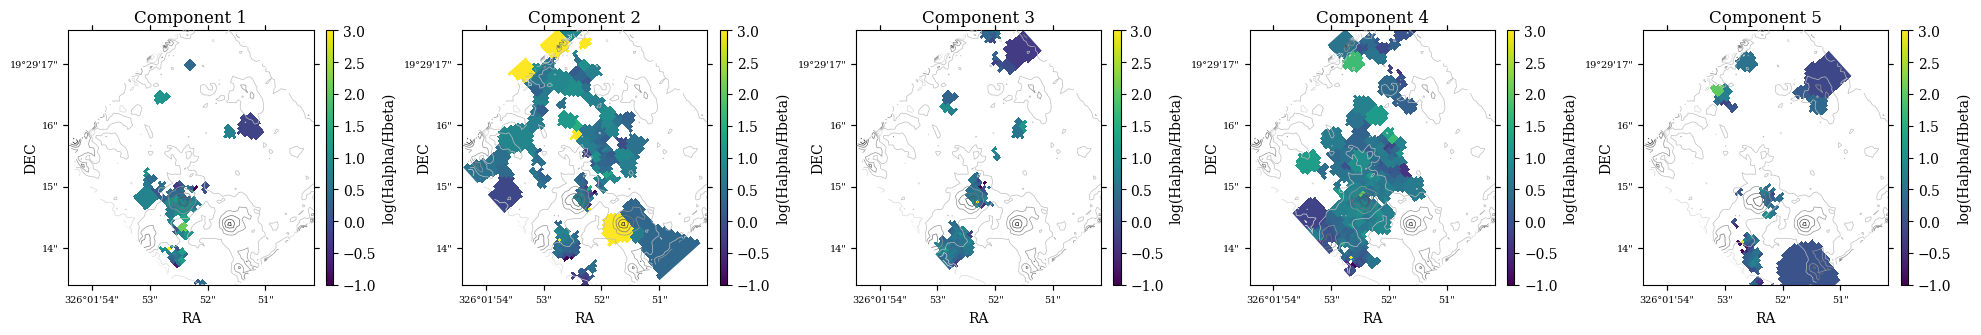

In [84]:
line_ratio_map_no_resampling(
    reverse_bin,
    "Halpha", "Halpha/output_from_OIII_binned/4C1971.line.npz",
    "Hbeta", "OIII/output_from_OIII_binned/4C1971.line.npz"
)

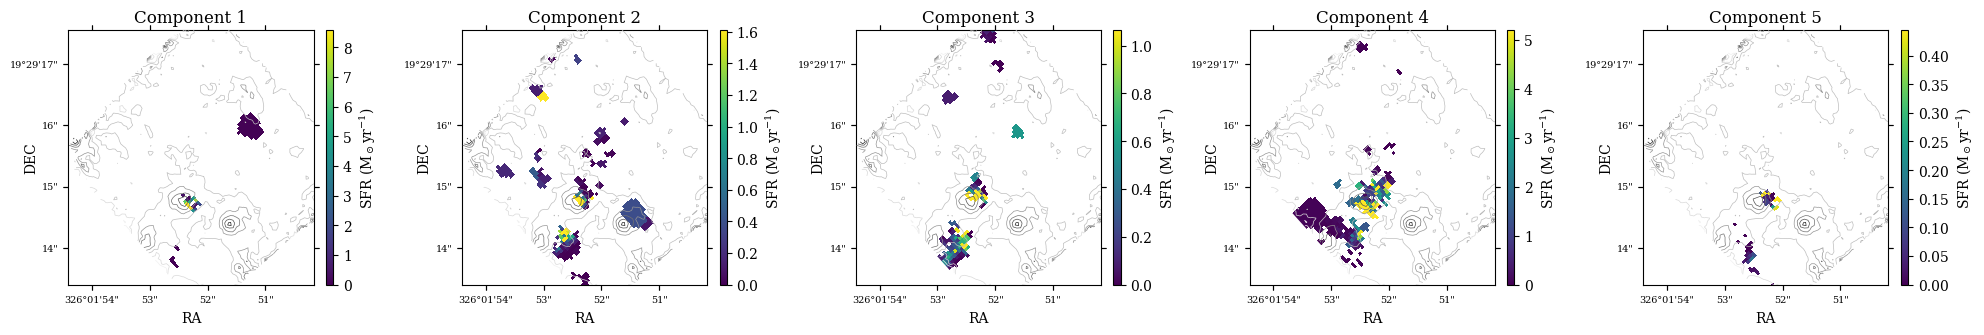

In [38]:
def sfr_map():
    np.seterr(all='ignore')
    contmap = np.load("contmap.npy")
    
    def get_data(file):
        file_data = np.load(file, allow_pickle=True)
        line_flux = file_data["emlflx"].item()
        line_fluxerr = file_data["emlflxerr"].item()
        line_sigma = file_data['emlsig'].item()
        line_ncomp = file_data['emlncomp'].item()
        return line_flux, line_fluxerr, line_sigma, line_ncomp
    
    line_list = ["Halpha", "Hbeta"]
    flux_list, fluxerr_list, sigma_list, ncomp_list = list(zip(get_data("Halpha/output_from_OIII_binned/4C1971.line.npz"), get_data("OIII/output_from_OIII_binned/4C1971.line.npz")))
    # flux_list, fluxerr_list, sigma_list, ncomp_list = list(zip(get_data("Halpha/output_from_OIII/4C1971.line.npz"), get_data("4C1971_neighbour_method.line.red.npz")))

    ncomp = np.max([int(np.nanmax(n[l])) for n, l in zip(ncomp_list, line_list)])
    fig2, axs2 = plt.subplots(1, ncomp, figsize=(20,4), subplot_kw={"projection": wcs_rot})
    # fig2.tight_layout(w_pad=5, h_pad=0)
    fig2.tight_layout(w_pad=2, h_pad=0)
    fig2.subplots_adjust(left=0.04, right=0.95, top=0.95, bottom=0.05)
    # fig2.tight_layout()

    for i in range(ncomp):
        # ignore spaxels without linefit
        for line, flux, fluxerr, sigma in zip(line_list, flux_list, fluxerr_list, sigma_list):
            mask = (sigma[f"c{i+1}"][line] == 0.)
            flux[f"fc{i+1}"][line][mask] = np.nan
            fluxerr[f"fc{i+1}"][line][mask] = np.nan


        ############################ dust
        flux_Halpha = flux_list[0][f"fc{i+1}"][line_list[0]]
        flux_Hbeta = flux_list[1][f"fc{i+1}"][line_list[1]]
        fluxerr_Hbeta = fluxerr_list[1][f"fc{i+1}"][line_list[1]]

        lambda_Halpha = list(linelist(["Halpha"])["lines"])[0]
        lambda_Hbeta = list(linelist(["Hbeta"])["lines"])[0]
        def extinction_curve(lamb):
            if 0.63 <= lamb < 2.2: #micron
                return 2.659 * (-1.857 + 1.040/lamb) + 4.05
            elif 0.12 <= lamb < 0.63:
                return 2.659 * (-2.156 + 1.509/lamb - 0.198/lamb**2 + 0.011/lamb**3) + 4.05
            else:
                raise ValueError
            
        # print(lambda_Halpha, lambda_Hbeta)
            
        color_excess = 2.5/(extinction_curve(lambda_Hbeta)-extinction_curve(lambda_Halpha)) * np.log10((flux_Halpha/flux_Hbeta)/2.86)
        color_excess = np.where(np.isinf(color_excess), np.nan, color_excess)

        flux_Halpha_corr = flux_Halpha * 10**(0.4*extinction_curve(lambda_Halpha)*color_excess)
        flux_Hbeta_corr = flux_Hbeta * 10**(0.4*extinction_curve(lambda_Hbeta)*color_excess)

        distance_cm = 31536 * 3.08568*10**24
        SFR = (4*np.pi * distance_cm**2 * flux_Halpha_corr * 10**(-17)) / (1.26*10**41)

        # data = flux_Hbeta/fluxerr_Hbeta
        data = np.where(flux_Hbeta/fluxerr_Hbeta>2, SFR, np.nan)
        nx, ny = data.shape
        lim = np.nanpercentile(data, 90)
        im_agn = axs2[i].imshow(reverse_bin(data).T, origin="lower", vmin=0, vmax=lim, interpolation="nearest", transform=rot+axs2[i].get_transform("pixel"))
        
        im_cont = axs2[i].contour(contmap, cmap="Greys", zorder=10, linewidths=0.5, transform=rot+axs2[i].get_transform("pixel"))
        
        cax2 = inset_axes(axs2[i], width="3%", height=f"100%", loc='lower left',
                        bbox_to_anchor=(1.05, 0.0, 1, 1), bbox_transform=axs2[i].transAxes, borderpad=0)
        
        cb2 = fig2.colorbar(im_agn, cax=cax2)
        
        cb2.set_label(r"SFR ($\mathrm{M}_\odot \mathrm{yr}^{-1}$)", loc="center")
        
        axs2[i].set_title(f"Component {i+1}")
        axs2[i].set_xlim(-10, nx)
        axs2[i].set_ylim(0, ny)
        axs2[i].set_xlabel("RA")
        axs2[i].set_ylabel("DEC", labelpad=-1.5)
        axs2[i].coords[0].set_major_formatter('dd:mm:ss')
        axs2[i].coords[0].set_ticklabel(size=7)
        axs2[i].coords[1].set_ticklabel(size=7)
    fig2.savefig(os.path.join("plots", f"star_formation_rate.pdf"))
sfr_map()

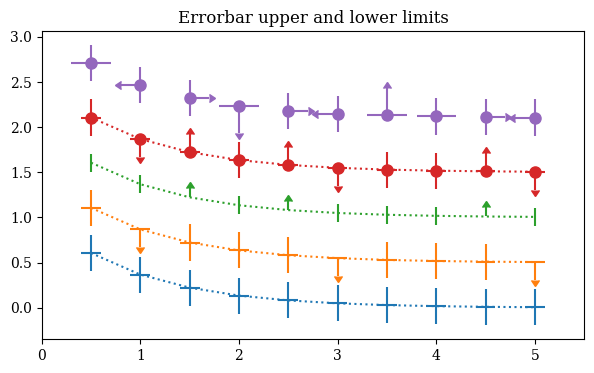

In [31]:
# example data
x = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
y = np.exp(-x)
xerr = 0.1
yerr = 0.2

# lower & upper limits of the error
lolims = np.array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0], dtype=bool)
uplims = np.array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1], dtype=bool)
ls = 'dotted'

fig, ax = plt.subplots(figsize=(7, 4))

# standard error bars
ax.errorbar(x, y, xerr=xerr, yerr=yerr, linestyle=ls)

# including upper limits
ax.errorbar(x, y + 0.5, xerr=xerr, yerr=yerr, uplims=uplims,
            linestyle=ls)

# including lower limits
ax.errorbar(x, y + 1.0, yerr=0.1, lolims=lolims,
            linestyle=ls)

# including upper and lower limits
ax.errorbar(x, y + 1.5, xerr=xerr, yerr=yerr,
            lolims=lolims, uplims=uplims,
            marker='o', markersize=8,
            linestyle=ls)

# Plot a series with lower and upper limits in both x & y
# constant x-error with varying y-error
xerr = 0.2
yerr = np.full_like(x, 0.2)
yerr[[3, 6]] = 0.3

# mock up some limits by modifying previous data
xlolims = lolims
xuplims = uplims
lolims = np.zeros_like(x)
uplims = np.zeros_like(x)
lolims[[6]] = True  # only limited at this index
uplims[[3]] = True  # only limited at this index

# do the plotting
ax.errorbar(x, y + 2.1, xerr=xerr, yerr=yerr,
            xlolims=xlolims, xuplims=xuplims,
            uplims=uplims, lolims=lolims,
            marker='o', markersize=8,
            linestyle='none')

# tidy up the figure
ax.set_xlim((0, 5.5))
ax.set_title('Errorbar upper and lower limits')
plt.show()

/tmp/ipykernel_12032/1901775250.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


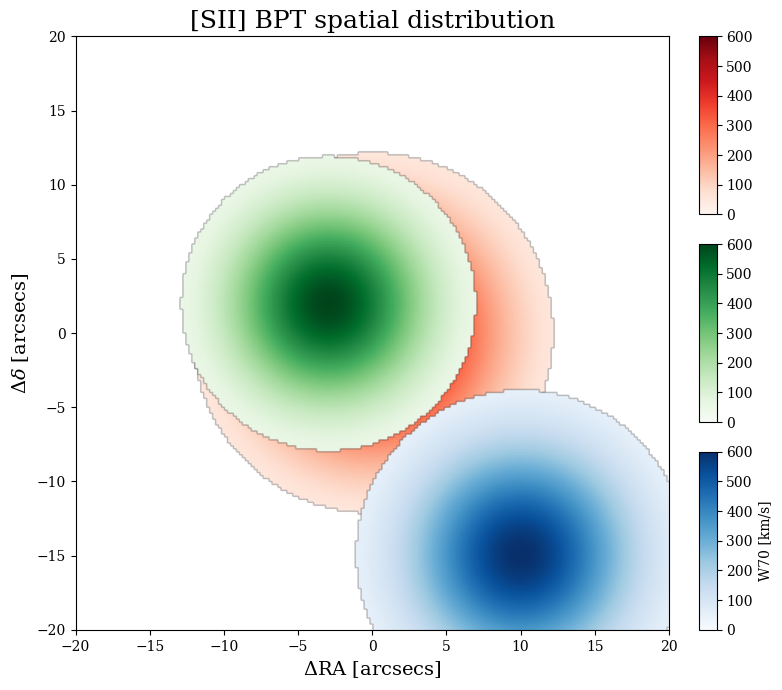

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -------------------------------------------------
# Mock spatial grid (replace with real data)
# -------------------------------------------------
np.random.seed(0)

x = np.linspace(-20, 20, 200)
y = np.linspace(-20, 20, 200)
X, Y = np.meshgrid(x, y)

Z_red   = 600 * np.exp(-(X**2 + Y**2)/60)
Z_green = 600 * np.exp(-((X+3)**2 + (Y-2)**2)/40)
Z_blue  = 600 * np.exp(-((X-10)**2 + (Y+15)**2)/50)

Z_red[Z_red < 50] = np.nan
Z_green[Z_green < 50] = np.nan
Z_blue[Z_blue < 50] = np.nan

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(7,7))

im1 = ax.imshow(Z_red, origin='lower',
                extent=[x.min(), x.max(), y.min(), y.max()],
                cmap='Reds', vmin=0, vmax=600)

im2 = ax.imshow(Z_green, origin='lower',
                extent=[x.min(), x.max(), y.min(), y.max()],
                cmap='Greens', vmin=0, vmax=600)

im3 = ax.imshow(Z_blue, origin='lower',
                extent=[x.min(), x.max(), y.min(), y.max()],
                cmap='Blues', vmin=0, vmax=600)

ax.set_title('[SII] BPT spatial distribution', fontsize=18)
ax.set_xlabel(r'$\Delta$RA [arcsecs]', fontsize=14)
ax.set_ylabel(r'$\Delta \delta$ [arcsecs]', fontsize=14)
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)

# -------------------------------------------------
# Three aligned colorbars
# -------------------------------------------------

# Height of each colorbar (in axes fraction)
cb_height = 0.3
spacing = 0.05

# Bottom colorbar aligned with bottom of plot
cax3 = inset_axes(ax,
                  width="3%",
                  height=f"{cb_height*100}%",
                  loc='lower left',
                  bbox_to_anchor=(1.05, 0.0, 1, 1),
                  bbox_transform=ax.transAxes,
                  borderpad=0)
cb3 = fig.colorbar(im3, cax=cax3)
cb3.set_label('W70 [km/s]')

# Middle
cax2 = inset_axes(ax,
                  width="3%",
                  height=f"{cb_height*100}%",
                  loc='lower left',
                  bbox_to_anchor=(1.05, cb_height + spacing, 1, 1),
                  bbox_transform=ax.transAxes,
                  borderpad=0)
cb2 = fig.colorbar(im2, cax=cax2)

# Top
cax1 = inset_axes(ax,
                  width="3%",
                  height=f"{cb_height*100}%",
                  loc='lower left',
                  bbox_to_anchor=(1.05, 2*(cb_height + spacing), 1, 1),
                  bbox_transform=ax.transAxes,
                  borderpad=0)
cb1 = fig.colorbar(im1, cax=cax1)

plt.tight_layout()
plt.show()